[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/arvidl/BMED365-2026/blob/main/Lab5-Comp-Mod/notebooks/06-kidney-filtration.ipynb)

# 06 — Kidney Filtration: Computational Physiology of GFR

**BMED365 – Computational Medicine (Lab 5)**

_Arvid Lundervold w/ Claude (Anthropic) & Grok (xAI) — 2025-02-23_<br>
_Updated: 2026-02-19_  (Cursor 2.5.17 with Claude Opus 4.6)

---

## 1. Motivation & Learning Objectives

### Why study kidney filtration?

The **kidneys** are among the most vital organs in the human body. Despite weighing only about 150 g each (roughly 0.4% of body weight), they receive approximately **20--25% of the cardiac output** --- about 1.2 liters of blood per minute. Every day, the kidneys filter roughly **180 liters** of plasma through their glomeruli, producing about 1.5 liters of urine. This extraordinary filtration machinery maintains the body's internal environment by:

- **Removing metabolic waste** --- urea, creatinine, uric acid, drug metabolites
- **Regulating fluid balance** --- adjusting water reabsorption to maintain blood volume and osmolarity
- **Maintaining electrolyte homeostasis** --- precise control of Na$^+$, K$^+$, Ca$^{2+}$, phosphate, and H$^+$/HCO$_3^-$
- **Controlling blood pressure** --- through the renin-angiotensin-aldosterone system (RAAS) and fluid volume regulation
- **Endocrine functions** --- producing erythropoietin (red blood cell production), activating vitamin D, and synthesizing prostaglandins

The **glomerular filtration rate (GFR)** is the single most important measure of kidney function. A decline in GFR signals kidney disease, which affects **~10--15% of the global adult population** (over 800 million people). Understanding how GFR is measured, modeled, and estimated is therefore of immense clinical importance.

### What you will learn

In this notebook you will:

1. **Understand** the anatomy of the kidney --- from the whole organ to the microscopic nephron --- and how structure enables function
2. **Appreciate** the historical journey --- from Carl Ludwig's filtration hypothesis (1842) to modern computational GFR estimation
3. **Master** the mathematical framework --- mass balance equations, the Starling equation, clearance concepts, and GFR estimation formulas
4. **Implement** a computational kidney filtration model in Python
5. **Visualize** and interpret filtration dynamics, mass balance, and the effects of pathological changes
6. **Explore** clinical applications --- CKD staging, drug dosing, dialysis, and non-invasive GFR estimation techniques (eGFR, MRI, nuclear medicine)

## 2. Historical Context: From Filtration Hypothesis to Computational GFR

### The quest to understand urine formation

How does the kidney produce urine? This question puzzled physiologists for centuries. The answer emerged gradually through a combination of anatomical observation, physiological experimentation, and mathematical modeling.

| Year | Milestone | Scientists |
|------|-----------|-----------:|
| 1666 | First detailed description of kidney microstructure | Marcello **Malpighi** |
| 1842 | **Filtration hypothesis**: proposed that urine formation begins with mechanical filtration of blood through glomerular capillaries | Carl **Ludwig** |
| 1844 | Described Bowman's capsule; proposed secretion theory | William **Bowman** |
| 1874 | Demonstrated that urine composition depends on blood flow | Rudolf **Heidenhain** |
| 1917 | Concept of "clearance" as a measure of kidney function | Arthur **Cushny** |
| 1926 | First practical clearance measurements using creatinine | Poul **Rehberg** |
| 1935 | Established **inulin clearance** as the gold standard for GFR measurement | Homer **Smith** |
| 1936 | PAH (para-aminohippuric acid) clearance for renal plasma flow (RPF) | Homer **Smith** |
| 1950s | Micropuncture studies confirming tubular function | A.N. **Richards** and others |
| 1969 | Cockcroft-Gault equation for estimated creatinine clearance | **Cockcroft** & **Gault** |
| 1976 | ${}^{99m}$Tc-DTPA and ${}^{51}$Cr-EDTA for nuclear medicine GFR | Various groups |
| 1999 | **MDRD equation** --- estimated GFR from serum creatinine | Andrew **Levey** et al. |
| 2009 | **CKD-EPI equation** --- improved eGFR, now the clinical standard | Andrew **Levey** et al. |
| 2021 | CKD-EPI equation updated to remove race coefficient | **Inker** et al. |

### Carl Ludwig and the filtration hypothesis

In 1842, the German physiologist **Carl Ludwig** (1816--1895) proposed a revolutionary idea: that urine formation begins as a purely physical process --- the mechanical **ultrafiltration** of blood plasma through the walls of the glomerular capillaries, driven by hydrostatic pressure. This was radical because it replaced vitalistic explanations with a quantitative, physics-based mechanism.

Ludwig's hypothesis was opposed by William Bowman, who favored a secretory theory. The debate persisted for decades until the micropuncture experiments of A.N. Richards in the 1920s--1940s directly confirmed that the fluid in Bowman's capsule is indeed an ultrafiltrate of plasma.

### Homer Smith: the father of renal physiology

**Homer W. Smith** (1895--1962) at New York University established the modern quantitative framework for kidney function. His key contributions include:

- Demonstrating that **inulin** (a fructose polymer from chicory root) is freely filtered at the glomerulus, not reabsorbed, and not secreted --- making its clearance equal to GFR
- Developing **PAH clearance** to measure effective renal plasma flow (ERPF)
- Writing the definitive textbook *The Kidney: Structure and Function in Health and Disease* (1951)
- Establishing the conceptual framework of clearance that is still used in nephrology today

> *"The kidney is the most important organ in the body. The brain merely serves to carry the kidney around."* --- Homer W. Smith (half-jokingly)

### From invasive to non-invasive GFR measurement

Historically, measuring GFR required invasive procedures: collecting timed urine samples over 24 hours while measuring plasma concentrations of a filtration marker (inulin or creatinine). These measurements are accurate but cumbersome, time-consuming, and impractical for routine clinical use.

The development of **estimated GFR (eGFR)** equations --- Cockcroft-Gault (1976), MDRD (1999), and CKD-EPI (2009, updated 2021) --- revolutionized nephrology by enabling GFR estimation from a **single blood test** (serum creatinine or cystatin C), combined with demographic variables (age, sex). Today, eGFR is automatically reported with every serum creatinine measurement in clinical laboratories worldwide.

In [ ]:
# --- Colab setup ---
import sys
if 'google.colab' in sys.modules:
    %pip install -q ipywidgets
    %matplotlib inline
else:
    %matplotlib inline

In [16]:
from IPython.display import Image, display, HTML

display(HTML("""
<figure style="text-align:center; margin: 20px 0;">
<img src="assets/kidney_anatomy.png"
     alt="Kidney anatomy cross-section" width="500"/>
<figcaption style="font-size:0.9em; color:#555; margin-top:8px;">
<b>Figure 1.</b> Cross-section of the human kidney showing the cortex, medulla (pyramids),
renal pelvis, and ureter. Blood enters via the renal artery and exits via the renal vein.
The functional unit &mdash; the <b>nephron</b> &mdash; spans cortex and medulla.
<br/><i>Source: Wikimedia Commons (public domain, by Piotr Micha&#322; Jaworski &mdash; PioM).</i>
</figcaption>
</figure>
"""))

## 3. The Kidney: Biological Background

### Gross anatomy

Each kidney is a bean-shaped organ (~12 cm long) located retroperitoneally on either side of the vertebral column. The key anatomical regions are:

- **Renal cortex** --- the outer region containing the glomeruli (where filtration occurs) and the proximal/distal convoluted tubules
- **Renal medulla** --- the inner region organized into cone-shaped **renal pyramids**, containing the loops of Henle and collecting ducts
- **Renal pelvis** --- a funnel-shaped cavity that collects urine from the collecting ducts and channels it to the ureter
- **Renal hilum** --- the entry/exit point for the renal artery, renal vein, and ureter

### The nephron: functional unit of the kidney

Each kidney contains approximately **1 million nephrons**. Each nephron consists of:

| Segment | Location | Primary function |
|---------|----------|-----------------|
| **Glomerulus** + **Bowman's capsule** | Cortex | Ultrafiltration of plasma |
| **Proximal convoluted tubule (PCT)** | Cortex | Reabsorbs ~65% of filtered water, Na$^+$, glucose, amino acids |
| **Loop of Henle** (descending/ascending) | Medulla | Creates osmotic gradient; concentrating mechanism |
| **Distal convoluted tubule (DCT)** | Cortex | Fine-tuning of Na$^+$, K$^+$, Ca$^{2+}$; regulated by aldosterone |
| **Collecting duct** | Medulla to pelvis | Final water reabsorption (regulated by ADH/vasopressin) |

### The glomerular filtration barrier

The filtration barrier in the glomerulus is a three-layered structure:

1. **Fenestrated endothelium** --- capillary wall with small pores (~70 nm) that allow passage of water and small solutes but block blood cells
2. **Glomerular basement membrane (GBM)** --- a dense extracellular matrix that filters by size and charge (negatively charged, repelling albumin)
3. **Podocytes** (visceral epithelial cells) --- specialized cells with interdigitating foot processes forming **filtration slits** (~40 nm)

This barrier allows free passage of water, electrolytes, and small molecules (glucose, urea, creatinine) while retaining large proteins (albumin, MW ~66 kDa) and blood cells in the circulation.

### The renal vasculature: a portal system

The kidney has a unique **double capillary bed** arrangement:

**Renal artery** $\to$ segmental arteries $\to$ interlobar $\to$ arcuate $\to$ **afferent arteriole** $\to$ **glomerular capillaries** (1st bed: filtration) $\to$ **efferent arteriole** $\to$ **peritubular capillaries** / **vasa recta** (2nd bed: reabsorption) $\to$ renal vein

This arrangement allows independent regulation of:
- **Glomerular filtration pressure** (by adjusting afferent/efferent arteriolar tone)
- **Peritubular reabsorption** (by adjusting Starling forces in peritubular capillaries)

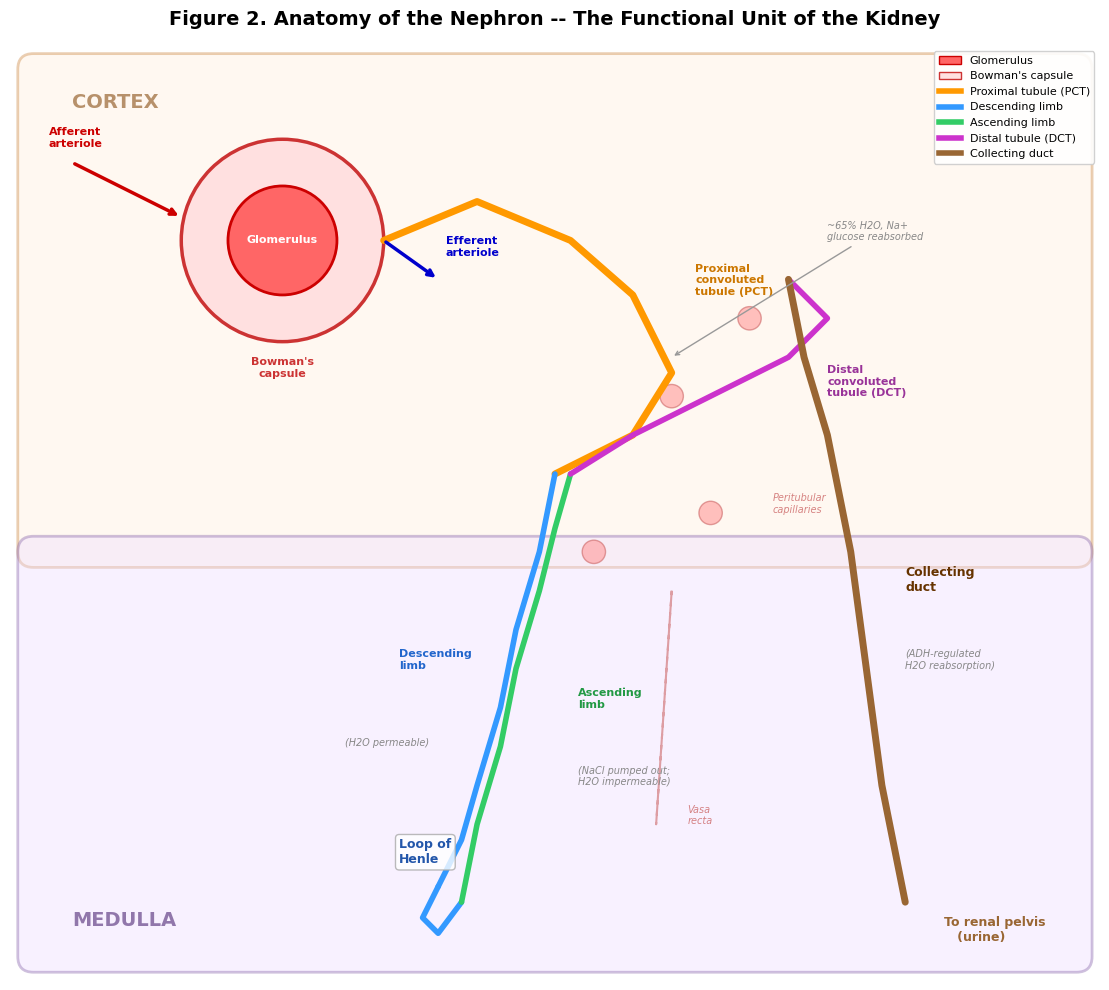

KEY FEATURES OF THE NEPHRON:
-------------------------------------------------------
  Each kidney has ~1 million nephrons
  Glomerulus: high-pressure filtration (GFR ~120 mL/min)
  PCT: bulk reabsorption (~65% of filtered load)
  Loop of Henle: counter-current concentrating mechanism
  DCT + Collecting duct: fine-tuning under hormonal control
  The nephron spans BOTH cortex and medulla


In [17]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch
import numpy as np
np.random.seed(42)

fig, ax = plt.subplots(figsize=(14, 10))
ax.set_xlim(0, 14)
ax.set_ylim(0, 12)
ax.set_aspect('equal')
ax.axis('off')

# Background regions
cortex = FancyBboxPatch((0.3, 5.5), 13.4, 6.2, boxstyle="round,pad=0.2",
                          facecolor='#ffeedd', edgecolor='#cc8844', lw=2, alpha=0.4)
ax.add_patch(cortex)
ax.text(0.8, 11.2, 'CORTEX', fontsize=14, fontweight='bold', color='#996633', alpha=0.7)

medulla = FancyBboxPatch((0.3, 0.3), 13.4, 5.2, boxstyle="round,pad=0.2",
                           facecolor='#eeddff', edgecolor='#8866aa', lw=2, alpha=0.4)
ax.add_patch(medulla)
ax.text(0.8, 0.7, 'MEDULLA', fontsize=14, fontweight='bold', color='#664488', alpha=0.7)

# Glomerulus + Bowman's capsule
bowman = plt.Circle((3.5, 9.5), 1.3, facecolor='#ffe0e0', edgecolor='#cc3333', lw=2.5)
ax.add_patch(bowman)
glom = plt.Circle((3.5, 9.5), 0.7, facecolor='#ff6666', edgecolor='#cc0000', lw=2)
ax.add_patch(glom)
ax.text(3.5, 9.5, 'Glomerulus', fontsize=8, ha='center', va='center',
        fontweight='bold', color='white')
ax.text(3.5, 8.0, "Bowman's\ncapsule", fontsize=8, ha='center', va='top',
        color='#cc3333', fontweight='bold')

# Afferent arteriole
ax.annotate('', xy=(2.2, 9.8), xytext=(0.8, 10.5),
            arrowprops=dict(arrowstyle='->', color='#cc0000', lw=2.5))
ax.text(0.5, 10.7, 'Afferent\narteriole', fontsize=8, color='#cc0000', fontweight='bold')

# Efferent arteriole
ax.annotate('', xy=(5.5, 9.0), xytext=(4.8, 9.5),
            arrowprops=dict(arrowstyle='->', color='#0000cc', lw=2.5))
ax.text(5.6, 9.3, 'Efferent\narteriole', fontsize=8, color='#0000cc', fontweight='bold')

# Proximal convoluted tubule (PCT)
pct_x = [4.8, 6.0, 7.2, 8.0, 8.5, 8.0, 7.0]
pct_y = [9.5, 10.0, 9.5, 8.8, 7.8, 7.0, 6.5]
ax.plot(pct_x, pct_y, '-', color='#ff9900', lw=5, solid_capstyle='round')
ax.text(8.8, 8.8, 'Proximal\nconvoluted\ntubule (PCT)', fontsize=8,
        color='#cc7700', fontweight='bold')
ax.annotate('~65% H2O, Na+\nglucose reabsorbed', xy=(8.5, 8.0), xytext=(10.5, 9.5),
            fontsize=7, color='#888', fontstyle='italic',
            arrowprops=dict(arrowstyle='->', color='#999', lw=1))

# Descending limb of Loop of Henle
desc_x = [7.0, 6.8, 6.5, 6.3, 6.0, 5.8, 5.5]
desc_y = [6.5, 5.5, 4.5, 3.5, 2.5, 1.8, 1.2]
ax.plot(desc_x, desc_y, '-', color='#3399ff', lw=4, solid_capstyle='round')
ax.text(5.0, 4.0, 'Descending\nlimb', fontsize=8, color='#2266cc', fontweight='bold')
ax.text(4.3, 3.0, '(H2O permeable)', fontsize=7, color='#888', fontstyle='italic')

# Hairpin turn
turn_x = [5.5, 5.3, 5.5, 5.8]
turn_y = [1.2, 0.8, 0.6, 1.0]
ax.plot(turn_x, turn_y, '-', color='#3399ff', lw=4, solid_capstyle='round')

# Ascending limb
asc_x = [5.8, 6.0, 6.3, 6.5, 6.8, 7.0, 7.2]
asc_y = [1.0, 2.0, 3.0, 4.0, 5.0, 5.8, 6.5]
ax.plot(asc_x, asc_y, '-', color='#33cc66', lw=4, solid_capstyle='round')
ax.text(7.3, 3.5, 'Ascending\nlimb', fontsize=8, color='#229944', fontweight='bold')
ax.text(7.3, 2.5, '(NaCl pumped out;\nH2O impermeable)', fontsize=7,
        color='#888', fontstyle='italic')

# Loop of Henle label
ax.text(5.0, 1.5, 'Loop of\nHenle', fontsize=9, color='#2255aa', fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                  edgecolor='#aaa', alpha=0.8))

# Distal convoluted tubule (DCT)
dct_x = [7.2, 8.0, 9.0, 10.0, 10.5, 10.0]
dct_y = [6.5, 7.0, 7.5, 8.0, 8.5, 9.0]
ax.plot(dct_x, dct_y, '-', color='#cc33cc', lw=4, solid_capstyle='round')
ax.text(10.5, 7.5, 'Distal\nconvoluted\ntubule (DCT)', fontsize=8,
        color='#993399', fontweight='bold')

# Collecting duct
cd_x = [10.0, 10.2, 10.5, 10.8, 11.0, 11.2, 11.5]
cd_y = [9.0, 8.0, 7.0, 5.5, 4.0, 2.5, 1.0]
ax.plot(cd_x, cd_y, '-', color='#996633', lw=5, solid_capstyle='round')
ax.text(11.5, 5.0, 'Collecting\nduct', fontsize=9, color='#663300', fontweight='bold')
ax.text(11.5, 4.0, '(ADH-regulated\nH2O reabsorption)', fontsize=7,
        color='#888', fontstyle='italic')

# Urine output arrow
ax.annotate('To renal pelvis\n   (urine)', xy=(11.5, 0.8), xytext=(12.0, 0.5),
            fontsize=9, color='#996633', fontweight='bold')

# Peritubular capillaries
for cx, cy in [(8.5, 7.5), (9.5, 8.5), (7.5, 5.5), (9.0, 6.0)]:
    cap = plt.Circle((cx, cy), 0.15, facecolor='#ff9999', edgecolor='#cc6666',
                       lw=1, alpha=0.6)
    ax.add_patch(cap)
ax.text(9.8, 6.0, 'Peritubular\ncapillaries', fontsize=7, color='#cc6666',
        fontstyle='italic', alpha=0.8)

# Vasa recta
ax.plot([8.5, 8.3, 8.5], [5.0, 2.0, 5.0], '--', color='#cc6666', lw=1.5, alpha=0.6)
ax.text(8.7, 2.0, 'Vasa\nrecta', fontsize=7, color='#cc6666',
        fontstyle='italic', alpha=0.8)

ax.set_title('Figure 2. Anatomy of the Nephron -- The Functional Unit of the Kidney',
             fontsize=14, fontweight='bold', pad=15)

legend_elements = [
    mpatches.Patch(facecolor='#ff6666', edgecolor='#cc0000', label='Glomerulus'),
    mpatches.Patch(facecolor='#ffe0e0', edgecolor='#cc3333', label="Bowman's capsule"),
    plt.Line2D([0], [0], color='#ff9900', lw=4, label='Proximal tubule (PCT)'),
    plt.Line2D([0], [0], color='#3399ff', lw=4, label='Descending limb'),
    plt.Line2D([0], [0], color='#33cc66', lw=4, label='Ascending limb'),
    plt.Line2D([0], [0], color='#cc33cc', lw=4, label='Distal tubule (DCT)'),
    plt.Line2D([0], [0], color='#996633', lw=4, label='Collecting duct'),
]
ax.legend(handles=legend_elements, loc='upper right', fontsize=8, framealpha=0.9)

plt.tight_layout()
plt.show()

print("KEY FEATURES OF THE NEPHRON:")
print("-" * 55)
print("  Each kidney has ~1 million nephrons")
print("  Glomerulus: high-pressure filtration (GFR ~120 mL/min)")
print("  PCT: bulk reabsorption (~65% of filtered load)")
print("  Loop of Henle: counter-current concentrating mechanism")
print("  DCT + Collecting duct: fine-tuning under hormonal control")
print("  The nephron spans BOTH cortex and medulla")

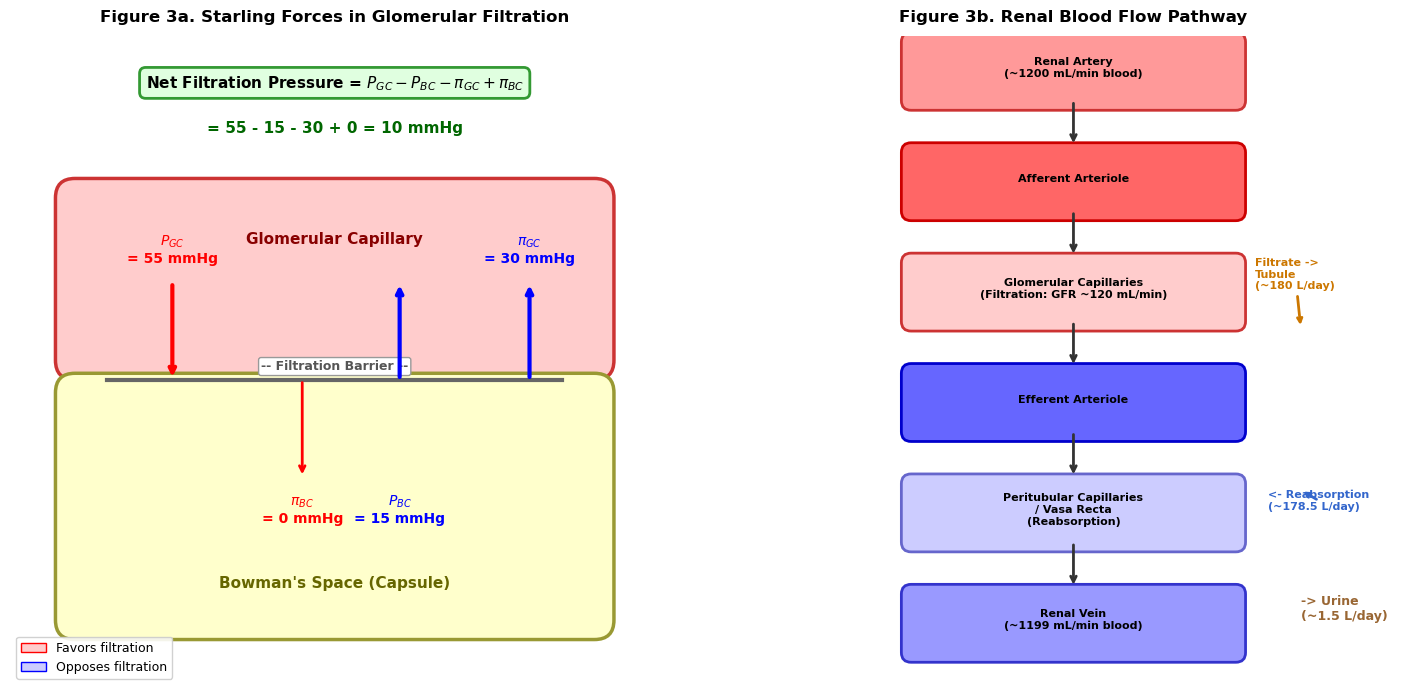

In [18]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch
import numpy as np

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 7))

# LEFT: Starling forces diagram
ax = ax1
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.set_aspect('equal')
ax.axis('off')

cap = FancyBboxPatch((1, 5), 8, 2.5, boxstyle="round,pad=0.3",
                      facecolor='#ffcccc', edgecolor='#cc3333', lw=2.5)
ax.add_patch(cap)
ax.text(5, 6.8, 'Glomerular Capillary', fontsize=11, ha='center',
        fontweight='bold', color='#880000')

bow = FancyBboxPatch((1, 1.0), 8, 3.5, boxstyle="round,pad=0.3",
                      facecolor='#ffffcc', edgecolor='#999933', lw=2.5)
ax.add_patch(bow)
ax.text(5, 1.5, "Bowman's Space (Capsule)", fontsize=11, ha='center',
        fontweight='bold', color='#666600')

ax.plot([1.5, 8.5], [4.7, 4.7], '-', color='#666', lw=3)
ax.text(5, 4.85, '-- Filtration Barrier --', fontsize=9, ha='center',
        color='#555', fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.2', facecolor='white', edgecolor='#999'))

# Forces FAVORING filtration
ax.annotate('', xy=(2.5, 4.7), xytext=(2.5, 6.2),
            arrowprops=dict(arrowstyle='->', color='red', lw=3))
ax.text(2.5, 6.5, '$P_{GC}$\n= 55 mmHg', fontsize=10, ha='center',
        color='red', fontweight='bold')

ax.annotate('', xy=(4.5, 4.7), xytext=(4.5, 3.2),
            arrowprops=dict(arrowstyle='<-', color='red', lw=2))
ax.text(4.5, 2.5, r'$\pi_{BC}$' + '\n= 0 mmHg', fontsize=10, ha='center',
        color='red', fontweight='bold')

# Forces OPPOSING filtration
ax.annotate('', xy=(6.0, 6.2), xytext=(6.0, 4.7),
            arrowprops=dict(arrowstyle='->', color='blue', lw=3))
ax.text(6.0, 2.5, '$P_{BC}$\n= 15 mmHg', fontsize=10, ha='center',
        color='blue', fontweight='bold')

ax.annotate('', xy=(8.0, 6.2), xytext=(8.0, 4.7),
            arrowprops=dict(arrowstyle='->', color='blue', lw=3))
ax.text(8.0, 6.5, r'$\pi_{GC}$' + '\n= 30 mmHg', fontsize=10, ha='center',
        color='blue', fontweight='bold')

# Net filtration box
ax.text(5, 9.2,
        r'Net Filtration Pressure = $P_{GC} - P_{BC} - \pi_{GC} + \pi_{BC}$',
        fontsize=11, ha='center', fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='#e0ffe0',
                  edgecolor='#339933', lw=2))
ax.text(5, 8.5, '= 55 - 15 - 30 + 0 = 10 mmHg', fontsize=11, ha='center',
        color='#006600', fontweight='bold')

ax.set_title('Figure 3a. Starling Forces in Glomerular Filtration',
             fontsize=12, fontweight='bold', pad=10)

legend_elements = [
    mpatches.Patch(facecolor='#ffcccc', edgecolor='red', label='Favors filtration'),
    mpatches.Patch(facecolor='#ccccff', edgecolor='blue', label='Opposes filtration'),
]
ax.legend(handles=legend_elements, loc='lower left', fontsize=9, framealpha=0.9)

# RIGHT: Blood flow diagram
ax = ax2
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.set_aspect('equal')
ax.axis('off')

boxes = [
    (5, 9.5, 'Renal Artery\n(~1200 mL/min blood)', '#ff9999', '#cc3333'),
    (5, 7.8, 'Afferent Arteriole', '#ff6666', '#cc0000'),
    (5, 6.1, 'Glomerular Capillaries\n(Filtration: GFR ~120 mL/min)', '#ffcccc', '#cc3333'),
    (5, 4.4, 'Efferent Arteriole', '#6666ff', '#0000cc'),
    (5, 2.7, 'Peritubular Capillaries\n/ Vasa Recta\n(Reabsorption)', '#ccccff', '#6666cc'),
    (5, 1.0, 'Renal Vein\n(~1199 mL/min blood)', '#9999ff', '#3333cc'),
]

for x, y, label, fc, ec in boxes:
    box = FancyBboxPatch((x - 2.5, y - 0.5), 5.0, 0.9, boxstyle="round,pad=0.15",
                          facecolor=fc, edgecolor=ec, lw=2)
    ax.add_patch(box)
    ax.text(x, y, label, fontsize=8, ha='center', va='center', fontweight='bold')

for i in range(len(boxes) - 1):
    y1 = boxes[i][1] - 0.5
    y2 = boxes[i+1][1] + 0.5
    ax.annotate('', xy=(5, y2), xytext=(5, y1),
                arrowprops=dict(arrowstyle='->', color='#333', lw=2))

ax.annotate('Filtrate ->\nTubule\n(~180 L/day)', xy=(8.5, 5.5), xytext=(7.8, 6.1),
            fontsize=8, color='#cc7700', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='#cc7700', lw=2))
ax.annotate('<- Reabsorption\n(~178.5 L/day)', xy=(8.5, 3.0), xytext=(8.0, 2.7),
            fontsize=8, color='#3366cc', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='#3366cc', lw=2))
ax.text(8.5, 1.0, '-> Urine\n(~1.5 L/day)', fontsize=9, color='#996633',
        fontweight='bold')

ax.set_title('Figure 3b. Renal Blood Flow Pathway',
             fontsize=12, fontweight='bold', pad=10)

plt.tight_layout()
plt.show()

### Check Your Understanding: Kidney Anatomy & Physiology

**Q1.** The kidneys receive ~20--25% of cardiac output, yet they constitute less than 0.5% of body weight. Why do the kidneys need such a disproportionately large blood supply?

<details>
<summary>Click to reveal answer</summary>

The kidneys' primary function is **filtration** --- they must process the entire blood volume many times per day to remove waste products and maintain homeostasis. The high blood flow serves two purposes:

1. **Filtration pressure**: The high flow rate through glomerular capillaries creates the hydrostatic pressure needed to drive ultrafiltration (~180 L/day of filtrate).
2. **Metabolic demand**: The kidney is a highly metabolic organ --- tubular reabsorption (especially in the PCT) requires enormous amounts of ATP for active transport (Na$^+$/K$^+$-ATPase). The high blood flow delivers the oxygen needed for this work.

Despite their small size, the kidneys consume about **10% of the body's total oxygen** at rest.

</details>

---

**Q2.** What would happen to GFR if the *afferent* arteriole constricts? What about if the *efferent* arteriole constricts?

<details>
<summary>Click to reveal answer</summary>

- **Afferent arteriole constriction** $\to$ **GFR decreases**. Constriction reduces blood flow *into* the glomerulus, lowering the glomerular capillary hydrostatic pressure ($P_{GC}$) and therefore reducing the net filtration pressure.

- **Efferent arteriole constriction** $\to$ **GFR increases** (up to a point). Constriction increases resistance *downstream* of the glomerulus, "backing up" blood in the glomerular capillaries and *increasing* $P_{GC}$. However, if efferent constriction is too severe, renal blood flow drops enough that $\pi_{GC}$ rises sharply (plasma proteins become more concentrated), eventually reducing GFR.

This is how **angiotensin II** helps maintain GFR during low blood pressure --- it preferentially constricts the efferent arteriole.

</details>

---

**Q3.** A patient's urine test shows significant amounts of albumin (a large protein, MW ~66 kDa). What does this suggest about the glomerular filtration barrier?

<details>
<summary>Click to reveal answer</summary>

Albumin is normally **almost completely retained** in the blood because of its size (~66 kDa) and negative charge (the GBM is also negatively charged, creating electrostatic repulsion). Finding significant albumin in the urine (**albuminuria** or **proteinuria**) suggests:

1. **Damage to the glomerular filtration barrier** --- possibly at the podocyte level (loss of foot processes = "effacement"), the GBM (loss of charge selectivity or structural integrity), or the fenestrated endothelium
2. Common causes include **diabetic nephropathy**, **glomerulonephritis**, **hypertensive nephrosclerosis**, and **minimal change disease**
3. Albuminuria is one of the earliest markers of kidney disease and is itself a risk factor for cardiovascular disease

**Microalbuminuria** (30--300 mg/day) is an early warning sign; **macroalbuminuria** (>300 mg/day) indicates significant glomerular damage.

</details>

## 4. Scientific and Clinical Implications

Understanding kidney filtration and GFR has profound implications across medicine and biomedical science:

### Chronic Kidney Disease (CKD)
- CKD affects **~10--15% of the global population** (~850 million people) and is a leading cause of death worldwide
- CKD is staged entirely based on **GFR** and **albuminuria**:

| Stage | GFR (mL/min/1.73 m$^2$) | Description |
|-------|----------------------|-------------|
| G1 | $\geq$ 90 | Normal or high (with other evidence of kidney damage) |
| G2 | 60--89 | Mildly decreased |
| G3a | 45--59 | Mildly to moderately decreased |
| G3b | 30--44 | Moderately to severely decreased |
| G4 | 15--29 | Severely decreased |
| G5 | < 15 | Kidney failure (may need dialysis or transplant) |

### Drug Dosing
- The kidney excretes many drugs and their metabolites. When GFR declines, drugs accumulate, causing **toxicity**
- **Dose adjustments** based on eGFR are mandatory for medications such as:
  - Antibiotics (gentamicin, vancomycin)
  - Anticoagulants (enoxaparin, dabigatran)
  - Diabetes medications (metformin --- contraindicated if eGFR < 30)
  - Contrast agents (risk of contrast-induced nephropathy)

### Dialysis & Transplantation
- When GFR drops below ~10--15 mL/min (**end-stage renal disease**, ESRD), the kidneys can no longer maintain homeostasis
- **Hemodialysis** uses an external semipermeable membrane and a countercurrent dialysate to mimic glomerular filtration --- sessions of 3--4 hours, 3 times per week
- **Peritoneal dialysis** uses the peritoneal membrane as the filtration surface
- **Kidney transplantation** remains the gold standard for ESRD but is limited by organ availability

### Imaging-Based GFR Measurement
- **Nuclear medicine**: ${}^{99m}$Tc-DTPA or ${}^{51}$Cr-EDTA clearance provides accurate GFR measurement
- **Dynamic contrast-enhanced MRI (DCE-MRI)**: Non-invasive measurement of single-kidney GFR using Gd-based contrast agents and pharmacokinetic modeling --- an active area of research that directly relates to computational modeling
- **Renal scintigraphy**: ${}^{99m}$Tc-MAG3 renogram for split renal function assessment

### The Kidney in Systemic Disease
- **Diabetes mellitus**: Leading cause of CKD; hyperglycemia damages the glomerular filtration barrier leading to diabetic nephropathy
- **Hypertension**: Both a cause and consequence of CKD; the RAAS is a key therapeutic target (ACE inhibitors, ARBs)
- **Heart failure**: Cardiorenal syndrome --- kidney and heart failure exacerbate each other through hemodynamic and neurohormonal mechanisms

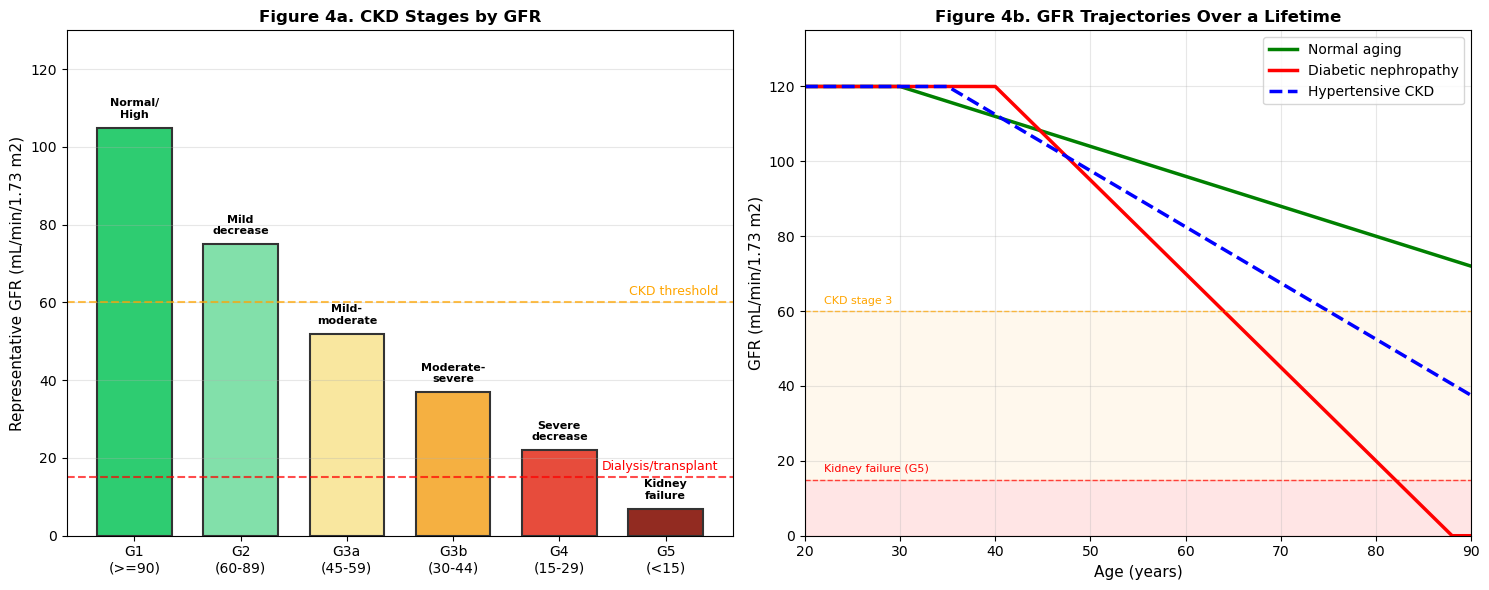

CLINICAL KEY POINTS:
-------------------------------------------------------
  Normal GFR ~ 120 mL/min/1.73 m2 (young adults)
  GFR naturally declines ~0.8 mL/min/year after age 30
  CKD is diagnosed when GFR < 60 mL/min/1.73 m2
  Dialysis is typically needed when GFR < 10-15
  Diabetes and hypertension accelerate GFR decline


In [19]:
import matplotlib.pyplot as plt
import numpy as np

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# LEFT: CKD Stages bar chart
stages = ['G1\n(>=90)', 'G2\n(60-89)', 'G3a\n(45-59)',
          'G3b\n(30-44)', 'G4\n(15-29)', 'G5\n(<15)']
gfr_mid = [105, 75, 52, 37, 22, 7]
colors = ['#2ecc71', '#82e0aa', '#f9e79f', '#f5b041', '#e74c3c', '#922b21']
descriptions = ['Normal/\nHigh', 'Mild\ndecrease', 'Mild-\nmoderate',
                'Moderate-\nsevere', 'Severe\ndecrease', 'Kidney\nfailure']

bars = ax1.bar(stages, gfr_mid, color=colors, edgecolor='#333', lw=1.5, width=0.7)
for bar, desc in zip(bars, descriptions):
    ax1.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 2,
             desc, ha='center', va='bottom', fontsize=8, fontweight='bold')

ax1.set_ylabel('Representative GFR (mL/min/1.73 m2)', fontsize=11)
ax1.set_title('Figure 4a. CKD Stages by GFR', fontsize=12, fontweight='bold')
ax1.set_ylim(0, 130)
ax1.axhline(y=60, color='orange', linestyle='--', lw=1.5, alpha=0.7)
ax1.text(5.5, 62, 'CKD threshold', fontsize=9, color='orange', ha='right')
ax1.axhline(y=15, color='red', linestyle='--', lw=1.5, alpha=0.7)
ax1.text(5.5, 17, 'Dialysis/transplant', fontsize=9, color='red', ha='right')
ax1.grid(axis='y', alpha=0.3)

# RIGHT: GFR decline with age
ages = np.arange(20, 91)
gfr_normal = np.clip(120 - 0.8 * (ages - 30), 60, 120)
gfr_normal[ages < 30] = 120
gfr_diabetic = np.clip(120 - 2.5 * (ages - 40), 0, 120)
gfr_diabetic[ages < 40] = 120
gfr_hypertensive = np.clip(120 - 1.5 * (ages - 35), 15, 120)
gfr_hypertensive[ages < 35] = 120

ax2.plot(ages, gfr_normal, 'g-', lw=2.5, label='Normal aging')
ax2.plot(ages, gfr_diabetic, 'r-', lw=2.5, label='Diabetic nephropathy')
ax2.plot(ages, gfr_hypertensive, 'b--', lw=2.5, label='Hypertensive CKD')

ax2.axhline(y=60, color='orange', linestyle='--', lw=1, alpha=0.7)
ax2.axhline(y=15, color='red', linestyle='--', lw=1, alpha=0.7)
ax2.text(22, 62, 'CKD stage 3', fontsize=8, color='orange')
ax2.text(22, 17, 'Kidney failure (G5)', fontsize=8, color='red')
ax2.axhspan(0, 15, alpha=0.1, color='red')
ax2.axhspan(15, 60, alpha=0.07, color='orange')

ax2.set_xlabel('Age (years)', fontsize=11)
ax2.set_ylabel('GFR (mL/min/1.73 m2)', fontsize=11)
ax2.set_title('Figure 4b. GFR Trajectories Over a Lifetime', fontsize=12,
              fontweight='bold')
ax2.legend(fontsize=10, loc='upper right')
ax2.set_xlim(20, 90)
ax2.set_ylim(0, 135)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("CLINICAL KEY POINTS:")
print("-" * 55)
print("  Normal GFR ~ 120 mL/min/1.73 m2 (young adults)")
print("  GFR naturally declines ~0.8 mL/min/year after age 30")
print("  CKD is diagnosed when GFR < 60 mL/min/1.73 m2")
print("  Dialysis is typically needed when GFR < 10-15")
print("  Diabetes and hypertension accelerate GFR decline")

## 5. Key Definitions and Concepts

### Glomerular Filtration Rate (GFR)

**GFR** is the volume of plasma filtered from the glomerular capillaries into Bowman's capsule per unit time. It is the **gold standard measure of kidney function**.

$$\boxed{\text{GFR} = K_f \times \underbrace{\left[(P_{GC} - P_{BC}) - (\pi_{GC} - \pi_{BC})\right]}_{\text{Net filtration pressure (NFP)}}}$$

where:
- $K_f$ = ultrafiltration coefficient (hydraulic permeability $\times$ surface area) [mL/min/mmHg]
- $P_{GC}$ = glomerular capillary hydrostatic pressure (~55 mmHg)
- $P_{BC}$ = Bowman's capsule hydrostatic pressure (~15 mmHg)
- $\pi_{GC}$ = glomerular capillary oncotic (colloid osmotic) pressure (~30 mmHg)
- $\pi_{BC}$ = Bowman's capsule oncotic pressure (~0 mmHg, since ultrafiltrate is protein-free)

**Normal value**: ~120 mL/min/1.73 m$^2$ (= ~180 L/day)

### Renal Plasma Flow (RPF)

The volume of plasma flowing through the kidneys per unit time. Measured using **PAH clearance** (since PAH is nearly completely extracted in a single pass):

$$\text{RPF} \approx \frac{U_{PAH} \times V}{P_{PAH}} \approx 600 \text{ mL/min}$$

### Filtration Fraction (FF)

The fraction of renal plasma flow that is filtered at the glomerulus:

$$\boxed{FF = \frac{\text{GFR}}{\text{RPF}} \approx \frac{120}{600} = 0.20 \quad (20\%)}$$

### Clearance

The **clearance** of a substance $X$ is the volume of plasma *completely cleared* of $X$ by the kidneys per unit time:

$$\boxed{C_X = \frac{U_X \times \dot{V}}{P_X}}$$

where $U_X$ is the urine concentration, $\dot{V}$ is the urine flow rate, and $P_X$ is the plasma concentration.

**Key principle**: If substance $X$ is *freely filtered, not reabsorbed, and not secreted*, then:

$$C_X = \text{GFR}$$

This is the basis for measuring GFR using **inulin clearance** (the gold standard) or estimating it from **creatinine clearance**.

### Substance handling by the nephron

| Substance | Filtered? | Reabsorbed? | Secreted? | Clearance vs. GFR |
|-----------|-----------|-------------|-----------|-------------------|
| **Inulin** | Yes (freely) | No | No | $C_{inulin} = \text{GFR}$ |
| **Glucose** | Yes | Yes (100%, normally) | No | $C_{glucose} = 0$ (normally) |
| **Creatinine** | Yes | No | Slightly | $C_{creatinine} \approx \text{GFR}$ (overestimates slightly) |
| **PAH** | Yes | No | Yes (completely) | $C_{PAH} = \text{RPF}$ |
| **Urea** | Yes | Partially reabsorbed | No | $C_{urea} < \text{GFR}$ |
| **Albumin** | No (too large) | --- | --- | $C_{albumin} \approx 0$ (normally) |

### Check Your Understanding: Key Concepts

**Q4.** A substance has a clearance *greater* than GFR (i.e., $C_X > C_{inulin}$). What does this tell you about how the nephron handles this substance?

<details>
<summary>Click to reveal answer</summary>

If $C_X > \text{GFR}$, the substance must be both **filtered** and **secreted** by the tubules. The additional secretion from peritubular capillaries into the tubular lumen means that more of the substance is cleared from the plasma than could be accounted for by filtration alone.

The extreme case is **PAH** (para-aminohippuric acid), which is so completely secreted that $C_{PAH} \approx \text{RPF}$ (renal plasma flow). At low plasma concentrations, nearly all PAH is removed from the blood in a single pass through the kidney.

General rule:
- $C_X < \text{GFR}$: net reabsorption (e.g., glucose, urea)
- $C_X = \text{GFR}$: filtered only, no net reabsorption or secretion (e.g., inulin)
- $C_X > \text{GFR}$: net secretion (e.g., PAH, creatinine)

</details>

---

**Q5.** A patient's serum creatinine level doubles from 1.0 to 2.0 mg/dL. Approximately how much has their GFR changed?

<details>
<summary>Click to reveal answer</summary>

At steady state, creatinine production equals creatinine excretion:

$$\text{Production} = \text{GFR} \times P_{creatinine}$$

If production is constant and serum creatinine doubles, then GFR must have **halved** (approximately):

$$\text{GFR}_{new} \approx \frac{\text{GFR}_{old}}{2}$$

This is a crucial clinical insight: **the relationship between GFR and serum creatinine is hyperbolic (reciprocal), not linear**. Early in kidney disease, a large drop in GFR produces only a small rise in creatinine (because the curve is steep). Later, even a small further drop in GFR causes a large rise in creatinine.

This is why serum creatinine alone is a **poor screening test** for early kidney disease --- it may remain in the "normal range" even when GFR has already dropped by 50%.

</details>

---

**Q6.** Why can't glucose clearance be used to measure GFR?

<details>
<summary>Click to reveal answer</summary>

Glucose is **freely filtered** at the glomerulus but then **completely reabsorbed** in the proximal convoluted tubule (via SGLT2 and SGLT1 transporters) --- under normal conditions, 100% of filtered glucose is reclaimed. Therefore:

$$C_{glucose} = \frac{U_{glucose} \times \dot{V}}{P_{glucose}} = 0 \quad \text{(normally, since } U_{glucose} = 0\text{)}$$

A clearance of zero tells us nothing about GFR. To measure GFR, we need a substance that is freely filtered but **not reabsorbed and not secreted** (like inulin).

Note: In **uncontrolled diabetes**, plasma glucose exceeds the tubular reabsorption maximum ($T_m \approx 375$ mg/min), and glucose "spills" into the urine (**glucosuria**). Even then, glucose clearance doesn't equal GFR because reabsorption is still occurring.

</details>

## 6. Mathematical Framework: Mass Balance and Filtration Modeling

### Mass balance for the kidney

The kidney can be modeled as a "black box" with inputs and outputs. For any substance $X$, conservation of mass at **steady state** requires:

$$\boxed{\underbrace{P_{X,a} \times \text{RPF}_a}_{\text{Arterial input}} = \underbrace{P_{X,v} \times \text{RPF}_v}_{\text{Venous output}} + \underbrace{U_X \times \dot{V}}_{\text{Urine output}}}$$

where:
- $P_{X,a}$, $P_{X,v}$ = arterial and venous plasma concentrations of $X$ [mmol/mL]
- $\text{RPF}_a$, $\text{RPF}_v$ = arterial and venous renal plasma flow [mL/min]
- $U_X$ = urine concentration of $X$ [mmol/mL]
- $\dot{V}$ = urine flow rate [mL/min]

**Note**: $\text{RPF}_v = \text{RPF}_a - \dot{V}$ (the venous plasma flow is reduced by the volume lost as urine).

### Clearance derivation from mass balance

The **renal extraction** of $X$ is:

$$E_X = \frac{P_{X,a} - P_{X,v}}{P_{X,a}} = \frac{U_X \times \dot{V}}{P_{X,a} \times \text{RPF}_a}$$

The **clearance** is then:

$$C_X = E_X \times \text{RPF}_a = \frac{U_X \times \dot{V}}{P_{X,a}}$$

### The Starling equation for glomerular filtration

The rate of fluid filtration across the glomerular capillary wall is governed by the **Starling equation**:

$$J_v = K_f \left[(P_{GC} - P_{BC}) - \sigma(\pi_{GC} - \pi_{BC})\right]$$

where:
- $J_v$ = volume filtration rate per unit area [mL/min/cm$^2$]
- $K_f$ = ultrafiltration coefficient [mL/min/mmHg]
- $\sigma$ = reflection coefficient ($\approx 1$ for proteins, $\approx 0$ for small solutes)

For the whole glomerulus:

$$\text{GFR} = K_f \times \text{NFP}$$

where NFP = net filtration pressure. With typical values:

$$\text{GFR} = K_f \times [(55 - 15) - (30 - 0)] = K_f \times 10 \text{ mmHg}$$

For GFR = 120 mL/min, this gives $K_f \approx 12$ mL/min/mmHg --- about 100 times higher than in most other capillary beds, reflecting the kidney's specialized filtration barrier.

### Dynamic model: GFR along the glomerular capillary

In reality, the oncotic pressure $\pi_{GC}$ *increases* along the length of the capillary as water is filtered out and plasma proteins become more concentrated:

$$\frac{d\pi_{GC}}{dx} = \frac{\pi_{GC}}{1 - \text{FF}(x)} \times \frac{d\text{FF}}{dx}$$

$$\frac{d\text{FF}}{dx} = \frac{K_f'}{RPF} \left[P_{GC} - P_{BC} - \pi_{GC}(x)\right]$$

where $K_f'$ is the ultrafiltration coefficient per unit length and $x$ is the position along the capillary. This means that **filtration pressure decreases along the capillary** and may reach zero before the end (a state called **filtration equilibrium**).

### Filtered load, excretion, and net handling

For a given substance $X$:

$$\text{Filtered load} = F_X = \text{GFR} \times P_X$$

$$\text{Excretion rate} = E_X = U_X \times \dot{V}$$

$$\text{Net reabsorption} = F_X - E_X \quad (\text{if positive})$$
$$\text{Net secretion} = E_X - F_X \quad (\text{if positive})$$

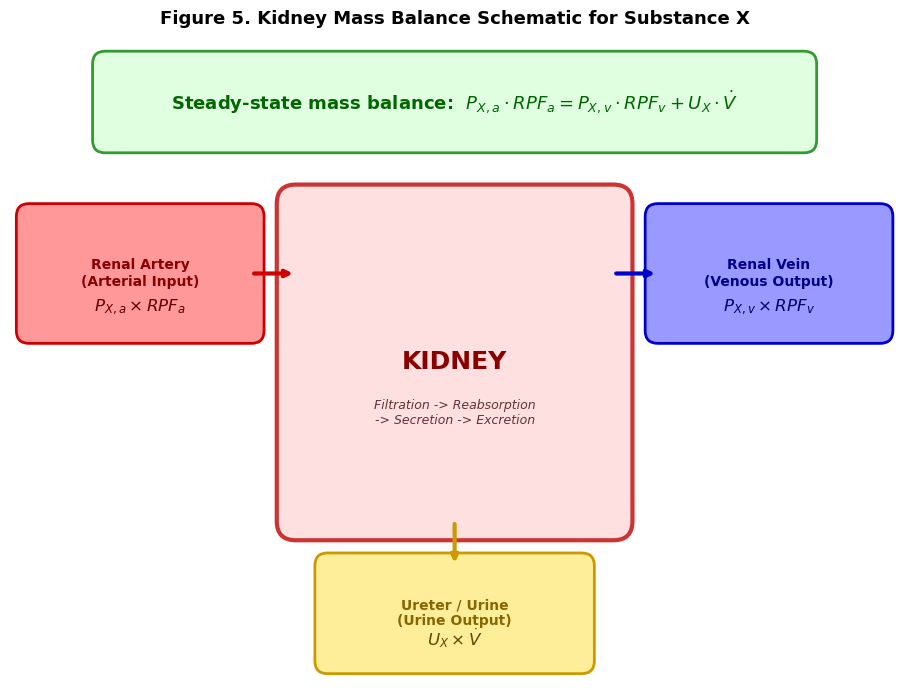

In [20]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch
import numpy as np

fig, ax = plt.subplots(figsize=(14, 7))
ax.set_xlim(0, 14)
ax.set_ylim(0, 10)
ax.set_aspect('equal')
ax.axis('off')

# Central kidney box
kidney = FancyBboxPatch((4.5, 2.5), 5.0, 5.0, boxstyle="round,pad=0.3",
                         facecolor='#ffe0e0', edgecolor='#cc3333', lw=3)
ax.add_patch(kidney)
ax.text(7.0, 5.0, 'KIDNEY', fontsize=18, ha='center', va='center',
        fontweight='bold', color='#880000')
ax.text(7.0, 4.2, 'Filtration -> Reabsorption\n-> Secretion -> Excretion',
        fontsize=9, ha='center', va='center', color='#663333', fontstyle='italic')

# Arterial input
art = FancyBboxPatch((0.3, 5.5), 3.5, 1.8, boxstyle="round,pad=0.2",
                      facecolor='#ff9999', edgecolor='#cc0000', lw=2)
ax.add_patch(art)
ax.text(2.05, 6.4, 'Renal Artery\n(Arterial Input)', fontsize=10, ha='center',
        va='center', fontweight='bold', color='#880000')
ax.text(2.05, 5.8, r'$P_{X,a} \times RPF_a$', fontsize=12, ha='center',
        color='#660000')
ax.annotate('', xy=(4.5, 6.4), xytext=(3.8, 6.4),
            arrowprops=dict(arrowstyle='->', color='#cc0000', lw=3))

# Venous output
ven = FancyBboxPatch((10.2, 5.5), 3.5, 1.8, boxstyle="round,pad=0.2",
                      facecolor='#9999ff', edgecolor='#0000cc', lw=2)
ax.add_patch(ven)
ax.text(11.95, 6.4, 'Renal Vein\n(Venous Output)', fontsize=10, ha='center',
        va='center', fontweight='bold', color='#000088')
ax.text(11.95, 5.8, r'$P_{X,v} \times RPF_v$', fontsize=12, ha='center',
        color='#000066')
ax.annotate('', xy=(10.2, 6.4), xytext=(9.5, 6.4),
            arrowprops=dict(arrowstyle='->', color='#0000cc', lw=3))

# Urine output
uri = FancyBboxPatch((5.0, 0.3), 4.0, 1.5, boxstyle="round,pad=0.2",
                      facecolor='#ffee99', edgecolor='#cc9900', lw=2)
ax.add_patch(uri)
ax.text(7.0, 1.05, 'Ureter / Urine\n(Urine Output)', fontsize=10, ha='center',
        va='center', fontweight='bold', color='#886600')
ax.text(7.0, 0.55, r'$U_X \times \dot{V}$', fontsize=12, ha='center',
        color='#664400')
ax.annotate('', xy=(7.0, 1.8), xytext=(7.0, 2.5),
            arrowprops=dict(arrowstyle='->', color='#cc9900', lw=3))

# Mass balance equation
eq_box = FancyBboxPatch((1.5, 8.5), 11.0, 1.2, boxstyle="round,pad=0.2",
                          facecolor='#e0ffe0', edgecolor='#339933', lw=2)
ax.add_patch(eq_box)
ax.text(7.0, 9.1,
        r'Steady-state mass balance:  $P_{X,a} \cdot RPF_a = P_{X,v} \cdot RPF_v + U_X \cdot \dot{V}$',
        fontsize=13, ha='center', va='center', fontweight='bold', color='#006600')

ax.set_title('Figure 5. Kidney Mass Balance Schematic for Substance X',
             fontsize=13, fontweight='bold', pad=15)

plt.tight_layout()
plt.show()

### Check Your Understanding: The Mathematics

**Q7.** A patient has the following measurements: plasma inulin concentration $P_{in}$ = 0.5 mg/mL, urine inulin concentration $U_{in}$ = 60 mg/mL, and urine flow rate $\dot{V}$ = 2 mL/min. Calculate the GFR.

<details>
<summary>Click to reveal answer</summary>

Since inulin is freely filtered, not reabsorbed, and not secreted:

$$\text{GFR} = C_{inulin} = \frac{U_{in} \times \dot{V}}{P_{in}} = \frac{60 \times 2}{0.5} = 240 \text{ mL/min}$$

Wait --- this is **twice normal**! This would be an unusually high GFR, which might indicate:
- Pregnancy (GFR normally increases ~50% during pregnancy due to increased renal blood flow)
- Early diabetes mellitus (hyperfiltration stage)
- A measurement or calculation error

In clinical practice, always check whether results are physiologically plausible!

</details>

---

**Q8.** Using the Starling equation, what would happen to GFR if a patient develops severe hypoalbuminemia (very low plasma albumin, e.g., from nephrotic syndrome)?

<details>
<summary>Click to reveal answer</summary>

Low plasma albumin leads to low plasma oncotic pressure ($\pi_{GC}$ decreases).

From the Starling equation:
$$\text{GFR} = K_f \times [(P_{GC} - P_{BC}) - (\pi_{GC} - \pi_{BC})]$$

If $\pi_{GC}$ decreases, the net filtration pressure **increases**, so GFR would **increase** --- at least initially.

However, the increased filtration leads to **more fluid and protein loss** into the urine, further depleting plasma proteins (a vicious cycle in nephrotic syndrome). The excess filtration also leads to **edema** as fluid shifts from the intravascular space to the interstitium due to reduced plasma oncotic pressure.

</details>

---

**Q9. (DIY --- Calculation)** A patient produces 1440 mL of urine per day with a creatinine concentration of 100 mg/dL. Their serum creatinine is 1.0 mg/dL. Calculate: (a) urine flow rate in mL/min, (b) creatinine clearance, (c) how this compares to normal GFR.

<details>
<summary>Click for hints</summary>

- Convert urine volume per day to mL/min: divide by number of minutes in a day (24 x 60 = 1440)
- Remember to use consistent units in the clearance formula
- Normal GFR is approximately 120 mL/min/1.73 m$^2$

</details>

<details>
<summary>Click to reveal answer</summary>

(a) Urine flow rate: $\dot{V} = \frac{1440 \text{ mL}}{1440 \text{ min}} = 1.0$ mL/min

(b) Creatinine clearance:
$$C_{cr} = \frac{U_{cr} \times \dot{V}}{P_{cr}} = \frac{100 \times 1.0}{1.0} = 100 \text{ mL/min}$$

(c) This is slightly below normal GFR (~120 mL/min). Since creatinine is slightly secreted by the tubules, creatinine clearance typically **overestimates** GFR by ~10--20%. So the true GFR here may be closer to ~85--90 mL/min, suggesting **mild kidney impairment** (CKD stage G2).

</details>

## 7. Python Implementation: Kidney Filtration Model

We now implement a computational model of kidney filtration based on the mass balance and Starling equation framework developed above. The model includes:

1. **Static mass balance** --- calculating steady-state substance handling
2. **Starling filtration** --- computing GFR from hemodynamic pressures
3. **Dynamic model** --- simulating how oncotic pressure changes along the glomerular capillary
4. **Clearance calculator** --- determining GFR from inulin/creatinine clearance data

In [21]:
# Kidney Filtration Computational Model
# BMED365 -- Computational Medicine (Lab 5)

import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass, field
from typing import Dict, Optional

@dataclass
class KidneyParams:
    '''Parameters for the kidney filtration model.

    All flow rates in mL/min, pressures in mmHg, concentrations in mmol/mL.
    '''
    # Hemodynamic parameters
    RPF_a: float = 600.0     # Renal plasma flow, arterial [mL/min]
    GFR: float = 120.0       # Glomerular filtration rate [mL/min]

    # Starling forces
    P_GC: float = 55.0       # Glomerular capillary hydrostatic pressure [mmHg]
    P_BC: float = 15.0       # Bowman's capsule hydrostatic pressure [mmHg]
    pi_GC: float = 30.0      # Glomerular capillary oncotic pressure [mmHg]
    pi_BC: float = 0.0       # Bowman's capsule oncotic pressure [mmHg]

    # Substance concentrations
    P_xa: float = 0.001      # Arterial concentration of substance X [mmol/mL]
    P_xv: float = 0.0009     # Venous concentration of substance X [mmol/mL]
    U_x: float = 0.06        # Urine concentration of substance X [mmol/mL]
    V_dot: float = 1.0       # Urine flow rate [mL/min]

    @property
    def RPF_v(self) -> float:
        '''Venous renal plasma flow = arterial - urine flow.'''
        return self.RPF_a - self.V_dot

    @property
    def FF(self) -> float:
        '''Filtration fraction.'''
        return self.GFR / self.RPF_a

    @property
    def K_f(self) -> float:
        '''Ultrafiltration coefficient [mL/min/mmHg].'''
        nfp = self.net_filtration_pressure
        return self.GFR / nfp if nfp > 0 else float('inf')

    @property
    def net_filtration_pressure(self) -> float:
        '''Net filtration pressure [mmHg].'''
        return (self.P_GC - self.P_BC) - (self.pi_GC - self.pi_BC)


class KidneyModel:
    '''Computational model of kidney filtration and mass balance.'''

    def __init__(self, params: Optional[KidneyParams] = None):
        self.params = params or KidneyParams()

    def mass_balance(self) -> Dict[str, float]:
        '''Calculate steady-state mass balance for substance X.'''
        p = self.params
        arterial_input = p.P_xa * p.RPF_a
        venous_output = p.P_xv * p.RPF_v
        urine_output = p.U_x * p.V_dot
        return {
            'arterial_input': arterial_input,
            'venous_output': venous_output,
            'urine_output': urine_output,
            'balance': arterial_input - (venous_output + urine_output),
            'extraction_ratio': (arterial_input - venous_output) / arterial_input
        }

    def filtered_load(self) -> float:
        '''Filtered load = GFR * arterial plasma concentration.'''
        return self.params.GFR * self.params.P_xa

    def clearance(self) -> float:
        '''Clearance of substance X = (U_x * V_dot) / P_xa.'''
        return (self.params.U_x * self.params.V_dot) / self.params.P_xa

    def starling_gfr(self, P_GC=None, P_BC=None, pi_GC=None, pi_BC=None,
                     K_f=None) -> float:
        '''Calculate GFR from Starling equation with optional parameter overrides.'''
        _P_GC = P_GC if P_GC is not None else self.params.P_GC
        _P_BC = P_BC if P_BC is not None else self.params.P_BC
        _pi_GC = pi_GC if pi_GC is not None else self.params.pi_GC
        _pi_BC = pi_BC if pi_BC is not None else self.params.pi_BC
        _K_f = K_f if K_f is not None else self.params.K_f

        nfp = (_P_GC - _P_BC) - (_pi_GC - _pi_BC)
        return _K_f * nfp

    def simulate_capillary_filtration(self, n_steps=100) -> Dict[str, np.ndarray]:
        '''Simulate filtration along the length of the glomerular capillary.

        As filtrate is removed, plasma proteins concentrate and oncotic
        pressure rises, reducing filtration pressure along the capillary.
        '''
        p = self.params
        x = np.linspace(0, 1, n_steps)
        dx = x[1] - x[0]

        pi_gc = np.zeros(n_steps)
        nfp = np.zeros(n_steps)
        cumulative_ff = np.zeros(n_steps)

        pi_gc[0] = p.pi_GC
        K_f_total = p.K_f

        for i in range(n_steps - 1):
            nfp[i] = (p.P_GC - p.P_BC) - (pi_gc[i] - p.pi_BC)
            nfp[i] = max(nfp[i], 0)

            d_ff = (K_f_total * nfp[i] / p.RPF_a) * dx
            cumulative_ff[i + 1] = cumulative_ff[i] + d_ff

            if cumulative_ff[i + 1] < 0.99:
                pi_gc[i + 1] = p.pi_GC / (1 - cumulative_ff[i + 1])
            else:
                pi_gc[i + 1] = pi_gc[i]

        nfp[-1] = max((p.P_GC - p.P_BC) - (pi_gc[-1] - p.pi_BC), 0)

        return {
            'position': x,
            'oncotic_pressure': pi_gc,
            'net_filtration_pressure': nfp,
            'cumulative_ff': cumulative_ff,
            'local_gfr': K_f_total * nfp
        }


# Create model and run simulations
params = KidneyParams(
    RPF_a=600, GFR=120,
    P_GC=55, P_BC=15, pi_GC=30, pi_BC=0,
    P_xa=0.001, P_xv=0.0009, U_x=0.06, V_dot=1.0
)

model = KidneyModel(params)

# Print results
print("=" * 60)
print("  KIDNEY FILTRATION MODEL -- BASELINE RESULTS")
print("=" * 60)

print(f"\n  Hemodynamics:")
print(f"    Renal plasma flow (arterial):  {params.RPF_a:.0f} mL/min")
print(f"    Renal plasma flow (venous):    {params.RPF_v:.0f} mL/min")
print(f"    GFR:                           {params.GFR:.0f} mL/min")
print(f"    Filtration fraction:           {params.FF:.1%}")

print(f"\n  Starling forces:")
print(f"    P_GC  = {params.P_GC:.0f} mmHg  (capillary hydrostatic)")
print(f"    P_BC  = {params.P_BC:.0f} mmHg  (Bowman's hydrostatic)")
print(f"    pi_GC = {params.pi_GC:.0f} mmHg  (capillary oncotic)")
print(f"    pi_BC = {params.pi_BC:.0f} mmHg   (Bowman's oncotic)")
print(f"    NFP   = {params.net_filtration_pressure:.0f} mmHg")
print(f"    K_f   = {params.K_f:.1f} mL/min/mmHg")

mb = model.mass_balance()
print(f"\n  Mass balance (for substance X):")
print(f"    Arterial input:    {mb['arterial_input']:.4f} mmol/min")
print(f"    Venous output:     {mb['venous_output']:.4f} mmol/min")
print(f"    Urine output:      {mb['urine_output']:.4f} mmol/min")
print(f"    Balance (~ 0):     {mb['balance']:.6f} mmol/min")
print(f"    Extraction ratio:  {mb['extraction_ratio']:.1%}")
print(f"    Filtered load:     {model.filtered_load():.4f} mmol/min")
print(f"    Clearance of X:    {model.clearance():.1f} mL/min")
print("=" * 60)

  KIDNEY FILTRATION MODEL -- BASELINE RESULTS

  Hemodynamics:
    Renal plasma flow (arterial):  600 mL/min
    Renal plasma flow (venous):    599 mL/min
    GFR:                           120 mL/min
    Filtration fraction:           20.0%

  Starling forces:
    P_GC  = 55 mmHg  (capillary hydrostatic)
    P_BC  = 15 mmHg  (Bowman's hydrostatic)
    pi_GC = 30 mmHg  (capillary oncotic)
    pi_BC = 0 mmHg   (Bowman's oncotic)
    NFP   = 10 mmHg
    K_f   = 12.0 mL/min/mmHg

  Mass balance (for substance X):
    Arterial input:    0.6000 mmol/min
    Venous output:     0.5391 mmol/min
    Urine output:      0.0600 mmol/min
    Balance (~ 0):     0.000900 mmol/min
    Extraction ratio:  10.1%
    Filtered load:     0.1200 mmol/min
    Clearance of X:    60.0 mL/min


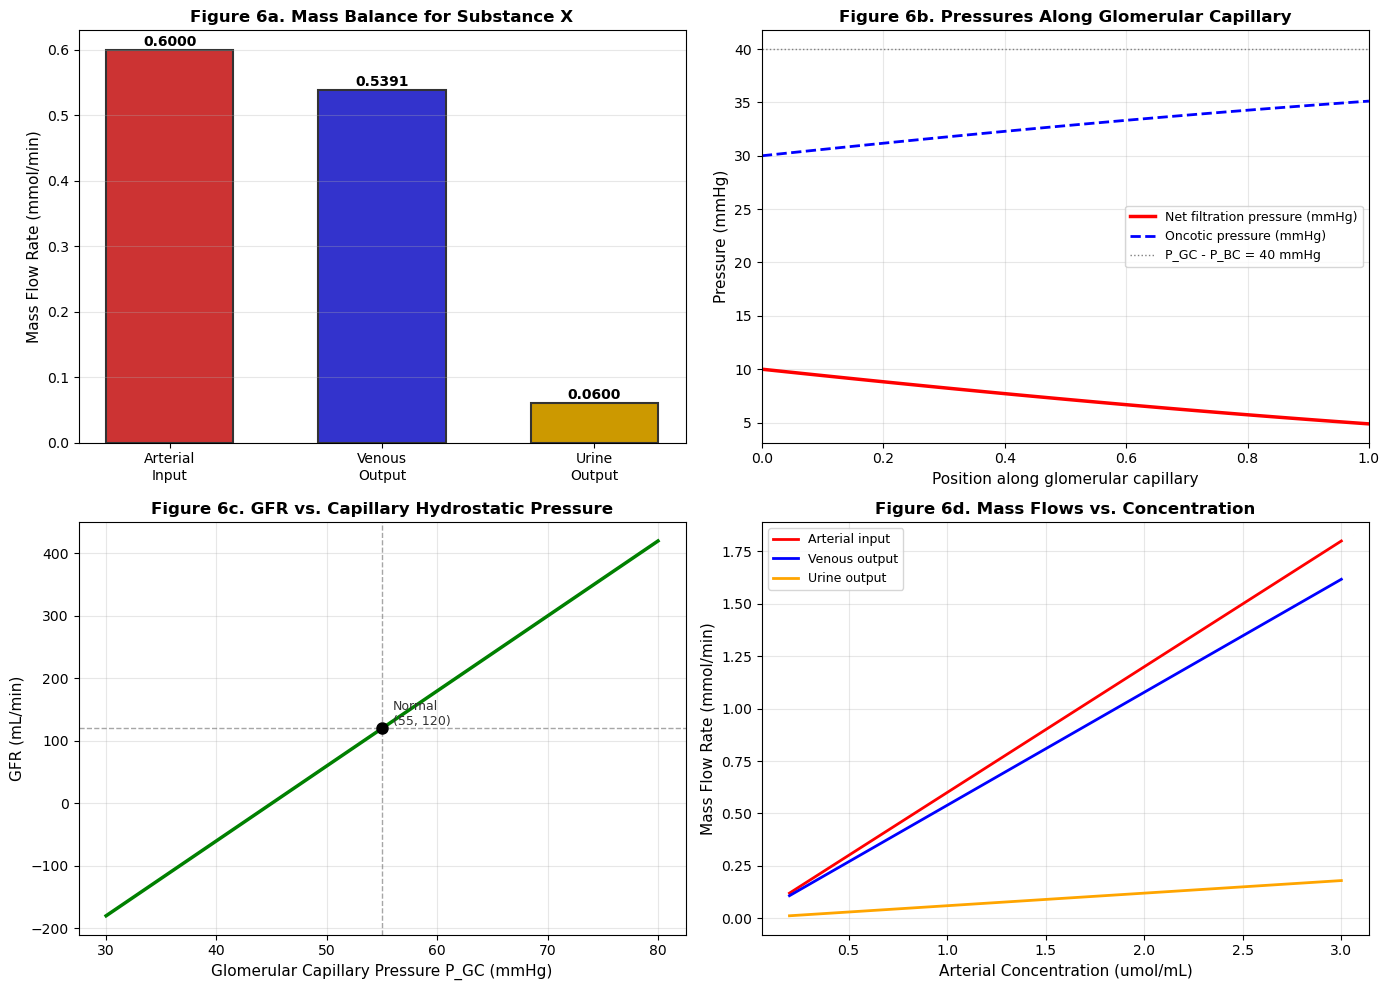

KEY OBSERVATIONS:
-------------------------------------------------------
  Panel (a): Mass balance is conserved (input = outputs)
  Panel (b): Oncotic pressure rises along the capillary
    as proteins concentrate, reducing NFP towards zero
  Panel (c): GFR increases linearly with P_GC (Starling)
  Panel (d): Mass flows scale linearly with concentration


In [22]:
# Visualizations

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Panel 1: Mass balance bar chart
ax = axes[0, 0]
mb = model.mass_balance()
components = ['Arterial\nInput', 'Venous\nOutput', 'Urine\nOutput']
values = [mb['arterial_input'], mb['venous_output'], mb['urine_output']]
colors = ['#cc3333', '#3333cc', '#cc9900']

bars = ax.bar(components, values, color=colors, edgecolor='#333', lw=1.5, width=0.6)
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.002,
            f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_ylabel('Mass Flow Rate (mmol/min)', fontsize=11)
ax.set_title('Figure 6a. Mass Balance for Substance X', fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

# Panel 2: Filtration along the capillary
ax = axes[0, 1]
cap_data = model.simulate_capillary_filtration()

ax.plot(cap_data['position'], cap_data['net_filtration_pressure'],
        'r-', lw=2.5, label='Net filtration pressure (mmHg)')
ax.plot(cap_data['position'], cap_data['oncotic_pressure'],
        'b--', lw=2, label='Oncotic pressure (mmHg)')
ax.axhline(y=params.P_GC - params.P_BC, color='gray', linestyle=':', lw=1,
           label=f'P_GC - P_BC = {params.P_GC - params.P_BC} mmHg')

ax.set_xlabel('Position along glomerular capillary', fontsize=11)
ax.set_ylabel('Pressure (mmHg)', fontsize=11)
ax.set_title('Figure 6b. Pressures Along Glomerular Capillary', fontsize=12,
             fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 1)

# Panel 3: Effect of P_GC on GFR
ax = axes[1, 0]
P_GC_range = np.linspace(30, 80, 50)
GFR_values = [model.starling_gfr(P_GC=p) for p in P_GC_range]

ax.plot(P_GC_range, GFR_values, 'g-', lw=2.5)
ax.axvline(x=55, color='gray', linestyle='--', lw=1, alpha=0.7)
ax.axhline(y=120, color='gray', linestyle='--', lw=1, alpha=0.7)
ax.plot(55, 120, 'ko', markersize=8, zorder=5)
ax.text(56, 125, 'Normal\n(55, 120)', fontsize=9, color='#333')

ax.set_xlabel('Glomerular Capillary Pressure P_GC (mmHg)', fontsize=11)
ax.set_ylabel('GFR (mL/min)', fontsize=11)
ax.set_title('Figure 6c. GFR vs. Capillary Hydrostatic Pressure', fontsize=12,
             fontweight='bold')
ax.grid(True, alpha=0.3)

# Panel 4: Effect of arterial concentration on mass flows
ax = axes[1, 1]
P_xa_range = np.linspace(0.0002, 0.003, 30)
art_inputs = []
ven_outputs = []
urine_outputs = []

for pxa in P_xa_range:
    test_params = KidneyParams(RPF_a=600, GFR=120, P_xa=pxa,
                                P_xv=pxa * 0.9, U_x=pxa * 60.0, V_dot=1.0)
    test_model = KidneyModel(test_params)
    mb_test = test_model.mass_balance()
    art_inputs.append(mb_test['arterial_input'])
    ven_outputs.append(mb_test['venous_output'])
    urine_outputs.append(mb_test['urine_output'])

ax.plot(P_xa_range * 1000, art_inputs, 'r-', lw=2, label='Arterial input')
ax.plot(P_xa_range * 1000, ven_outputs, 'b-', lw=2, label='Venous output')
ax.plot(P_xa_range * 1000, urine_outputs, 'orange', lw=2, label='Urine output')

ax.set_xlabel('Arterial Concentration (umol/mL)', fontsize=11)
ax.set_ylabel('Mass Flow Rate (mmol/min)', fontsize=11)
ax.set_title('Figure 6d. Mass Flows vs. Concentration', fontsize=12,
             fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("KEY OBSERVATIONS:")
print("-" * 55)
print("  Panel (a): Mass balance is conserved (input = outputs)")
print("  Panel (b): Oncotic pressure rises along the capillary")
print("    as proteins concentrate, reducing NFP towards zero")
print("  Panel (c): GFR increases linearly with P_GC (Starling)")
print("  Panel (d): Mass flows scale linearly with concentration")

### Interpreting the Simulation Results (Figure 6)

**Panel (a) --- Mass Balance**: The bar chart confirms that the total arterial input of substance X equals the sum of venous and urine outputs. This is the fundamental mass conservation principle.

**Panel (b) --- Filtration Along the Capillary**: As blood flows through the glomerular capillary, water is filtered out and plasma proteins become more concentrated, causing oncotic pressure ($\pi_{GC}$) to rise. This progressively reduces the net filtration pressure. In some conditions, filtration may cease before the end of the capillary (filtration equilibrium).

**Panel (c) --- GFR vs. Pressure**: The linear relationship between $P_{GC}$ and GFR (from the Starling equation) shows why blood pressure regulation is critical for kidney function. A drop in $P_{GC}$ (e.g., from hemorrhage or heart failure) directly reduces GFR.

**Panel (d) --- Concentration Dependence**: For a substance handled passively (no transport maximum), mass flows scale linearly with arterial concentration. In reality, substances like glucose have a **transport maximum ($T_m$)** --- beyond which they "spill" into the urine.

### Interactive Glomerular Filtration Simulator

Use the sliders below to explore how **Starling forces** and the **ultrafiltration coefficient** determine GFR. The left panel shows the instantaneous Starling balance; the right panel shows how oncotic pressure rises and net filtration pressure falls along the glomerular capillary as plasma is concentrated.

The simulation is governed by the **Starling equation**:

$$\text{GFR} = K_f \times \underbrace{\left[(P_{GC} - P_{BC}) - (\pi_{GC} - \pi_{BC})\right]}_{\text{Net Filtration Pressure (NFP)}}$$

#### Adjustable parameters

| Parameter | Symbol | Description | Normal | Range | Unit |
|:----------|:------:|:------------|:------:|:-----:|:-----|
| Glomerular capillary hydrostatic pressure | $P_{GC}$ | Blood pressure inside the glomerular capillary; the main driving force for filtration | 55 | 30–80 | mmHg |
| Bowman's capsule hydrostatic pressure | $P_{BC}$ | Fluid pressure in Bowman's space; **opposes** filtration (rises in obstruction) | 15 | 0–30 | mmHg |
| Glomerular capillary oncotic pressure | $\pi_{GC}$ | Osmotic pressure from plasma proteins; **opposes** filtration (falls in nephrotic syndrome) | 30 | 10–50 | mmHg |
| Bowman's capsule oncotic pressure | $\pi_{BC}$ | Oncotic pressure of the filtrate; normally ≈ 0 because the filtration barrier excludes proteins | 0 | 0–10 | mmHg |
| Ultrafiltration coefficient | $K_f$ | Product of capillary hydraulic conductivity and surface area; reduced in glomerulonephritis | 12 | 2–25 | mL/min/mmHg |
| Renal plasma flow | RPF | Plasma flow entering the glomerulus; determines how quickly oncotic pressure rises along the capillary | 600 | 200–1000 | mL/min |

Try the **preset scenarios** to see how common clinical conditions alter filtration dynamics.

In [23]:
from ipywidgets import FloatSlider, VBox, HBox, Button, Output, Layout, HTML as WHTML
import ipywidgets as widgets

# ---------------------------------------------------------------------------
#  Slider definitions
# ---------------------------------------------------------------------------
style = {'description_width': '100px'}
sl_layout = Layout(width='420px')

sl_PGC = FloatSlider(value=55, min=30, max=80, step=1,
                     description='P_GC (mmHg):', style=style, layout=sl_layout,
                     readout_format='.0f')
sl_PBC = FloatSlider(value=15, min=0, max=30, step=1,
                     description='P_BC (mmHg):', style=style, layout=sl_layout,
                     readout_format='.0f')
sl_piGC = FloatSlider(value=30, min=10, max=50, step=1,
                      description='π_GC (mmHg):', style=style, layout=sl_layout,
                      readout_format='.0f')
sl_piBC = FloatSlider(value=0, min=0, max=10, step=0.5,
                      description='π_BC (mmHg):', style=style, layout=sl_layout,
                      readout_format='.1f')
sl_Kf = FloatSlider(value=12, min=2, max=25, step=0.5,
                    description='K_f (mL/min/mmHg):', style=style, layout=sl_layout,
                    readout_format='.1f')
sl_RPF = FloatSlider(value=600, min=200, max=1000, step=10,
                     description='RPF (mL/min):', style=style, layout=sl_layout,
                     readout_format='.0f')

all_sliders = [sl_PGC, sl_PBC, sl_piGC, sl_piBC, sl_Kf, sl_RPF]

# ---------------------------------------------------------------------------
#  Preset clinical scenarios
# ---------------------------------------------------------------------------
presets = {
    'Normal':                 dict(P_GC=55, P_BC=15, pi_GC=30, pi_BC=0,  K_f=12,  RPF=600),
    'Hypertension':           dict(P_GC=70, P_BC=15, pi_GC=30, pi_BC=0,  K_f=12,  RPF=650),
    'Renal artery stenosis':  dict(P_GC=35, P_BC=15, pi_GC=30, pi_BC=0,  K_f=12,  RPF=300),
    'Nephrotic syndrome':     dict(P_GC=55, P_BC=15, pi_GC=15, pi_BC=0,  K_f=12,  RPF=600),
    'Ureteral obstruction':  dict(P_GC=55, P_BC=30, pi_GC=30, pi_BC=0,  K_f=12,  RPF=600),
    'Diabetic hyperfiltration': dict(P_GC=65, P_BC=15, pi_GC=28, pi_BC=0, K_f=16, RPF=750),
    'Glomerulonephritis':     dict(P_GC=55, P_BC=15, pi_GC=30, pi_BC=0,  K_f=5,   RPF=500),
}

preset_buttons = []
for name in presets:
    b = Button(description=name, layout=Layout(width='auto'),
               button_style='info' if name == 'Normal' else '')
    preset_buttons.append(b)

def _set_preset(btn):
    vals = presets[btn.description]
    sl_PGC.value, sl_PBC.value = vals['P_GC'], vals['P_BC']
    sl_piGC.value, sl_piBC.value = vals['pi_GC'], vals['pi_BC']
    sl_Kf.value, sl_RPF.value = vals['K_f'], vals['RPF']

for b in preset_buttons:
    b.on_click(_set_preset)

# ---------------------------------------------------------------------------
#  Simulation + plotting
# ---------------------------------------------------------------------------
out = Output()

def _update(*_):
    P_GC  = sl_PGC.value
    P_BC  = sl_PBC.value
    pi_GC = sl_piGC.value
    pi_BC = sl_piBC.value
    K_f   = sl_Kf.value
    RPF   = sl_RPF.value

    NFP = (P_GC - P_BC) - (pi_GC - pi_BC)
    GFR = max(K_f * NFP, 0)
    FF  = GFR / RPF if RPF > 0 else 0

    # --- capillary filtration profile ---
    n = 200
    x = np.linspace(0, 1, n)
    dx = x[1] - x[0]
    pi_cap = np.zeros(n)
    nfp_cap = np.zeros(n)
    cum_ff = np.zeros(n)
    pi_cap[0] = pi_GC

    for i in range(n - 1):
        nfp_cap[i] = max((P_GC - P_BC) - (pi_cap[i] - pi_BC), 0)
        d_ff = (K_f * nfp_cap[i] / RPF) * dx if RPF > 0 else 0
        cum_ff[i + 1] = cum_ff[i] + d_ff
        pi_cap[i + 1] = pi_GC / (1 - cum_ff[i + 1]) if cum_ff[i + 1] < 0.99 else pi_cap[i]
    nfp_cap[-1] = max((P_GC - P_BC) - (pi_cap[-1] - pi_BC), 0)

    with out:
        out.clear_output(wait=True)
        fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

        # ---- Panel A: Starling force balance bar chart ----
        ax = axes[0]
        forces = [P_GC, -P_BC, -pi_GC, pi_BC]
        labels = [f'$P_{{GC}}$\n{P_GC:.0f}',
                  f'$P_{{BC}}$\n−{P_BC:.0f}',
                  f'$\\pi_{{GC}}$\n−{pi_GC:.0f}',
                  f'$\\pi_{{BC}}$\n+{pi_BC:.1f}']
        colors_bar = ['#e74c3c', '#3498db', '#2ecc71', '#9b59b6']
        ax.bar(range(4), forces, color=colors_bar, edgecolor='k', linewidth=0.8)
        ax.set_xticks(range(4))
        ax.set_xticklabels(labels, fontsize=10)
        ax.axhline(0, color='k', lw=0.6)
        ax.set_ylabel('Pressure (mmHg)')

        nfp_color = '#27ae60' if NFP > 0 else '#c0392b'
        gfr_str = f'{GFR:.0f}' if GFR < 1e4 else '>9999'
        title_a = (f'Starling Balance    NFP = {NFP:.1f} mmHg\n'
                   f'GFR = {gfr_str} mL/min    FF = {FF:.1%}')
        ax.set_title(title_a, fontsize=11, color=nfp_color if NFP <= 0 else 'k')
        ax.set_ylim(min(forces) - 10, max(forces) + 10)

        # ---- Panel B: Capillary filtration profile ----
        ax2 = axes[1]
        ax2.plot(x * 100, nfp_cap, 'r-', lw=2, label='Net filtration pressure')
        ax2.fill_between(x * 100, 0, nfp_cap, alpha=0.15, color='red')
        ax2.set_xlabel('Position along capillary (%)')
        ax2.set_ylabel('Pressure (mmHg)', color='r')
        ax2.tick_params(axis='y', labelcolor='r')
        ax2.set_ylim(bottom=-2, top=max(25, max(nfp_cap) * 1.15))
        ax2.axhline(0, color='k', lw=0.5, ls='--')

        ax2b = ax2.twinx()
        ax2b.plot(x * 100, pi_cap, 'b-', lw=2, label='Oncotic π_GC(x)')
        ax2b.plot(x * 100, np.full(n, P_GC - P_BC), 'k--', lw=1,
                  alpha=0.5, label=f'$P_{{GC}}−P_{{BC}}$ = {P_GC-P_BC:.0f}')
        ax2b.set_ylabel('Oncotic pressure (mmHg)', color='b')
        ax2b.tick_params(axis='y', labelcolor='b')
        ax2b.set_ylim(bottom=0, top=max(60, pi_cap.max() * 1.15))

        lines1, labels1 = ax2.get_legend_handles_labels()
        lines2, labels2 = ax2b.get_legend_handles_labels()
        ax2.legend(lines1 + lines2, labels1 + labels2, fontsize=8, loc='upper left')

        eq_idx = np.argmax(nfp_cap < 0.5)
        if eq_idx > 0 and nfp_cap[eq_idx] < 0.5:
            ax2.axvline(x[eq_idx] * 100, color='gray', ls=':', lw=1)
            ax2.text(x[eq_idx] * 100 + 1, ax2.get_ylim()[1] * 0.9,
                     'filtration\nequilibrium', fontsize=8, color='gray')
        ax2.set_title(f'Filtration Along Capillary  (FF = {cum_ff[-1]:.1%})',
                      fontsize=11)

        plt.tight_layout()
        plt.show()

for sl in all_sliders:
    sl.observe(_update, names='value')

btn_row = HBox(preset_buttons, layout=Layout(flex_flow='row wrap', gap='4px'))
slider_col = VBox(all_sliders)
display(WHTML('<b>Preset clinical scenarios:</b>'))
display(btn_row)
display(slider_col)
display(out)

_update()

HTML(value='<b>Preset clinical scenarios:</b>')

Output()

### Check Your Understanding: Simulation

**Q10.** In Figure 6b, what would happen to the oncotic pressure curve if the patient had **hypoalbuminemia** (low plasma albumin)?

<details>
<summary>Click to reveal answer</summary>

With hypoalbuminemia, the **starting oncotic pressure** $\pi_{GC}$ would be **lower** (e.g., 15 mmHg instead of 30 mmHg). This means:
1. The initial NFP would be **higher** (more filtration pressure available)
2. The oncotic pressure would still rise along the capillary but start from a lower baseline
3. **Filtration equilibrium** would be reached later (or not at all)
4. Total GFR would be **increased**

However, this excessive filtration contributes to edema and further protein loss --- a hallmark of nephrotic syndrome.

</details>

---

**Q11. (DIY --- Coding Challenge)** Modify the `KidneyParams` to simulate **renal artery stenosis** (narrowing of the renal artery). Reduce `RPF_a` to 300 mL/min and `P_GC` to 35 mmHg. How does this affect GFR, filtration fraction, and mass balance?

<details>
<summary>Click for starter code</summary>

```python
# Renal artery stenosis simulation
stenosis_params = KidneyParams(
    RPF_a=300, GFR=60,
    P_GC=35, P_BC=15, pi_GC=30, pi_BC=0,
    P_xa=0.001, P_xv=0.0009, U_x=0.06, V_dot=0.5
)
stenosis_model = KidneyModel(stenosis_params)

# Compare with normal
print(f"Normal FF: {params.FF:.1%} vs Stenosis FF: {stenosis_params.FF:.1%}")
print(f"Normal GFR: {params.GFR} vs Stenosis GFR: {stenosis_params.GFR}")
```

</details>

<details>
<summary>Click to reveal what you should see</summary>

- GFR drops from 120 to ~60 mL/min (halved)
- The reduced $P_{GC}$ (35 vs 55 mmHg) reduces NFP from 10 to **-10 mmHg** --- meaning that with these parameters, filtration would actually **cease**! In reality, the body compensates by reducing $P_{BC}$ and activating the RAAS system.

This is why **bilateral renal artery stenosis** is a medical emergency --- it can cause acute kidney failure. ACE inhibitors are contraindicated in this setting because they prevent the efferent arteriolar constriction that is maintaining GFR.

</details>

## 8. Clinical GFR Estimation: From Bench to Bedside

### Why we need estimated GFR (eGFR)

Measuring true GFR using inulin clearance is the gold standard but requires:
- Continuous IV infusion of inulin
- Timed urine collections (often over 24 hours)
- Multiple blood and urine samples
- It is expensive, time-consuming, and impractical for routine clinical use

In clinical practice, GFR is therefore **estimated** from endogenous biomarkers --- substances naturally present in the blood whose levels reflect kidney function.

### Creatinine: the workhorse biomarker

**Creatinine** is a waste product from muscle metabolism (breakdown of creatine phosphate):
- Produced at a roughly constant rate (~1--2 g/day, proportional to muscle mass)
- Freely filtered at the glomerulus
- Not reabsorbed, but **slightly secreted** (~10--20% overestimation of GFR)
- Steady-state plasma level depends on the balance between production and clearance

### The CKD-EPI Equation (2021)

The current clinical standard for eGFR is the **CKD-EPI (Chronic Kidney Disease Epidemiology Collaboration)** equation, updated in 2021 to remove the race coefficient:

$$\text{eGFR} = 142 \times \min(S_{cr}/\kappa, 1)^{\alpha} \times \max(S_{cr}/\kappa, 1)^{-1.200} \times 0.9938^{\text{Age}} \times F_{sex}$$

where:
- $S_{cr}$ = serum creatinine [mg/dL]
- $\kappa$ = 0.7 (female) or 0.9 (male)
- $\alpha$ = $-$0.241 (female) or $-$0.302 (male)
- $F_{sex}$ = 1.012 (female) or 1.0 (male)

### Cystatin C: an alternative biomarker

**Cystatin C** is a small protein produced at a constant rate by all nucleated cells:
- Less influenced by muscle mass, diet, or race than creatinine
- Freely filtered, completely reabsorbed and catabolized by tubular cells (not appearing in urine)
- Useful when creatinine-based estimates may be unreliable (e.g., in patients with abnormal muscle mass)

The CKD-EPI cystatin C equation provides an alternative estimate, and combined creatinine-cystatin C equations offer the best accuracy.

In [24]:
# eGFR Calculator -- CKD-EPI 2021 (race-free)

def egfr_ckd_epi_2021(scr, age, sex):
    '''Calculate eGFR using the 2021 CKD-EPI creatinine equation (race-free).

    Parameters:
        scr: Serum creatinine in mg/dL
        age: Age in years
        sex: 'M' or 'F'

    Returns:
        eGFR in mL/min/1.73 m^2
    '''
    if sex.upper() == 'F':
        kappa, alpha, f_sex = 0.7, -0.241, 1.012
    else:
        kappa, alpha, f_sex = 0.9, -0.302, 1.0

    scr_kappa = scr / kappa
    egfr = (142
            * min(scr_kappa, 1.0) ** alpha
            * max(scr_kappa, 1.0) ** (-1.200)
            * 0.9938 ** age
            * f_sex)
    return egfr


def ckd_stage(egfr):
    '''Return CKD stage based on eGFR value.'''
    if egfr >= 90:   return "G1 (Normal or high)"
    if egfr >= 60:   return "G2 (Mildly decreased)"
    if egfr >= 45:   return "G3a (Mild-moderate decrease)"
    if egfr >= 30:   return "G3b (Moderate-severe decrease)"
    if egfr >= 15:   return "G4 (Severely decreased)"
    return "G5 (Kidney failure)"


# Demo: eGFR for different clinical scenarios
print("=" * 65)
print("  eGFR CALCULATOR -- CKD-EPI 2021 (Race-Free)")
print("=" * 65)

cases = [
    ("Healthy 25y female",       0.8, 25, 'F'),
    ("Healthy 25y male",         1.0, 25, 'M'),
    ("Healthy 60y female",       0.9, 60, 'F'),
    ("Healthy 60y male",         1.1, 60, 'M'),
    ("Mild CKD, 55y male",      1.5, 55, 'M'),
    ("Moderate CKD, 70y female", 2.0, 70, 'F'),
    ("Severe CKD, 65y male",    4.0, 65, 'M'),
    ("Kidney failure, 50y male", 8.0, 50, 'M'),
]

header = f"  {'Description':<30s} {'SCr':>5s} {'Age':>4s} {'Sex':>4s} {'eGFR':>7s}  {'Stage'}"
print(f"\n{header}")
print("  " + "-" * 85)

for desc, scr, age, sex in cases:
    e = egfr_ckd_epi_2021(scr, age, sex)
    stage = ckd_stage(e)
    print(f"  {desc:<30s} {scr:>5.1f} {age:>4d} {sex:>4s} {e:>7.1f}  {stage}")

print("=" * 65)

  eGFR CALCULATOR -- CKD-EPI 2021 (Race-Free)

  Description                      SCr  Age  Sex    eGFR  Stage
  -------------------------------------------------------------------------------------
  Healthy 25y female               0.8   25    F   104.8  G1 (Normal or high)
  Healthy 25y male                 1.0   25    M   107.1  G1 (Normal or high)
  Healthy 60y female               0.9   60    F    73.2  G2 (Mildly decreased)
  Healthy 60y male                 1.1   60    M    76.9  G2 (Mildly decreased)
  Mild CKD, 55y male               1.5   55    M    54.6  G3a (Mild-moderate decrease)
  Moderate CKD, 70y female         2.0   70    F    26.4  G4 (Severely decreased)
  Severe CKD, 65y male             4.0   65    M    15.8  G4 (Severely decreased)
  Kidney failure, 50y male         8.0   50    M     7.6  G5 (Kidney failure)


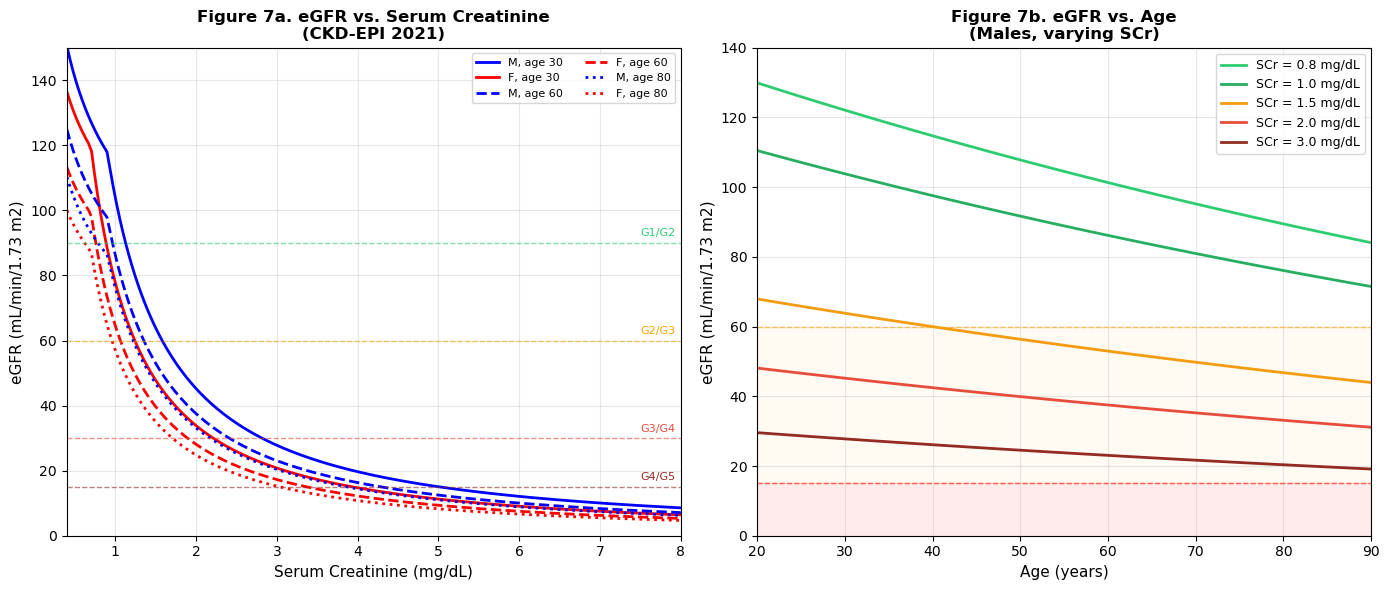

KEY INSIGHTS:
-------------------------------------------------------
  The eGFR-creatinine relationship is HYPERBOLIC
  -> A doubling of SCr ~ halving of GFR
  Early CKD: large GFR drop causes small SCr rise
    (SCr is a POOR early screening test!)
  Late CKD: small GFR drop causes large SCr rise
  eGFR decreases with age (aging kidney)
  Sex differences reflect differences in muscle mass


In [25]:
# Visualization: eGFR vs. Serum Creatinine

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# LEFT: eGFR vs serum creatinine (hyperbolic relationship)
scr_range = np.linspace(0.4, 8.0, 200)

for age, sex, color, ls in [(30, 'M', 'blue', '-'), (30, 'F', 'red', '-'),
                             (60, 'M', 'blue', '--'), (60, 'F', 'red', '--'),
                             (80, 'M', 'blue', ':'), (80, 'F', 'red', ':')]:
    egfr_vals = [egfr_ckd_epi_2021(s, age, sex) for s in scr_range]
    label = f'{sex}, age {age}'
    ax1.plot(scr_range, egfr_vals, color=color, linestyle=ls, lw=2, label=label)

for gfr_thresh, stage_label, clr in [(90, 'G1/G2', '#2ecc71'), (60, 'G2/G3', 'orange'),
                                      (30, 'G3/G4', '#e74c3c'), (15, 'G4/G5', '#922b21')]:
    ax1.axhline(y=gfr_thresh, color=clr, linestyle='--', lw=1, alpha=0.6)
    ax1.text(7.5, gfr_thresh + 2, stage_label, fontsize=8, color=clr)

ax1.set_xlabel('Serum Creatinine (mg/dL)', fontsize=11)
ax1.set_ylabel('eGFR (mL/min/1.73 m2)', fontsize=11)
ax1.set_title('Figure 7a. eGFR vs. Serum Creatinine\n(CKD-EPI 2021)',
              fontsize=12, fontweight='bold')
ax1.legend(fontsize=8, ncol=2)
ax1.set_xlim(0.4, 8)
ax1.set_ylim(0, 150)
ax1.grid(True, alpha=0.3)

# RIGHT: eGFR decline with age
ages = np.arange(20, 91)

for scr, color in [(0.8, '#2ecc71'), (1.0, '#27ae60'), (1.5, '#f39c12'),
                    (2.0, '#e74c3c'), (3.0, '#922b21')]:
    egfr_age = [egfr_ckd_epi_2021(scr, a, 'M') for a in ages]
    ax2.plot(ages, egfr_age, color=color, lw=2, label=f'SCr = {scr} mg/dL')

ax2.axhline(y=60, color='orange', linestyle='--', lw=1, alpha=0.6)
ax2.axhline(y=15, color='red', linestyle='--', lw=1, alpha=0.6)
ax2.axhspan(0, 15, alpha=0.08, color='red')
ax2.axhspan(15, 60, alpha=0.05, color='orange')

ax2.set_xlabel('Age (years)', fontsize=11)
ax2.set_ylabel('eGFR (mL/min/1.73 m2)', fontsize=11)
ax2.set_title('Figure 7b. eGFR vs. Age\n(Males, varying SCr)',
              fontsize=12, fontweight='bold')
ax2.legend(fontsize=9)
ax2.set_xlim(20, 90)
ax2.set_ylim(0, 140)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("KEY INSIGHTS:")
print("-" * 55)
print("  The eGFR-creatinine relationship is HYPERBOLIC")
print("  -> A doubling of SCr ~ halving of GFR")
print("  Early CKD: large GFR drop causes small SCr rise")
print("    (SCr is a POOR early screening test!)")
print("  Late CKD: small GFR drop causes large SCr rise")
print("  eGFR decreases with age (aging kidney)")
print("  Sex differences reflect differences in muscle mass")

### Check Your Understanding: Clinical GFR Estimation

**Q12.** A 45-year-old male bodybuilder has a serum creatinine of 1.5 mg/dL. His eGFR (CKD-EPI) calculates to ~55 mL/min, suggesting CKD stage G3a. Is this likely accurate? What might you do next?

<details>
<summary>Click to reveal answer</summary>

This is likely a **false positive** for CKD. Bodybuilders have **high muscle mass**, which leads to **higher creatinine production** and therefore higher baseline serum creatinine --- even with perfectly normal kidney function.

Steps to investigate:
1. **Cystatin C-based eGFR**: Cystatin C is not affected by muscle mass and would likely show a normal GFR
2. **24-hour urine creatinine clearance**: Direct measurement, though cumbersome
3. **Measured GFR** (iohexol or inulin clearance): The gold standard if there is clinical uncertainty
4. **Clinical context**: Is there proteinuria? Hematuria? Risk factors for kidney disease?

This case illustrates a key limitation of creatinine-based eGFR: it assumes "average" muscle mass and diet. Always interpret eGFR in the clinical context.

</details>

---

**Q13.** Why was the race coefficient removed from the CKD-EPI equation in 2021?

<details>
<summary>Click to reveal answer</summary>

The original CKD-EPI (2009) and MDRD equations included a **"Black race" coefficient** that gave higher eGFR values for Black patients. This was based on the observation that, on average, Black individuals had higher creatinine levels (attributed to higher average muscle mass). However:

1. **Race is a social construct**, not a biological variable --- there is more genetic variation *within* racial groups than between them
2. The coefficient was derived from **population-level averages** and may not apply to individual patients
3. Using the coefficient could lead to **underdiagnosis of CKD** in Black patients (by inflating their eGFR), delaying referral to nephrologists and access to transplant waitlists
4. It perpetuated **structural racism** in clinical algorithms

The 2021 update (Inker et al., *NEJM*) uses a **race-free equation** that performs comparably across populations, especially when combined with cystatin C.

</details>

---

**Q14. (DIY)** Using the `egfr_ckd_epi_2021` function, create a plot showing how eGFR changes with age for a person whose serum creatinine is 1.0 mg/dL. Compare male vs. female trajectories. At what age does each cross into CKD stage G2 territory (eGFR < 90)?

<details>
<summary>Click for starter code</summary>

```python
ages = np.arange(20, 100)
egfr_male = [egfr_ckd_epi_2021(1.0, a, 'M') for a in ages]
egfr_female = [egfr_ckd_epi_2021(1.0, a, 'F') for a in ages]

plt.figure(figsize=(10, 5))
plt.plot(ages, egfr_male, 'b-', lw=2, label='Male')
plt.plot(ages, egfr_female, 'r-', lw=2, label='Female')
plt.axhline(y=90, color='green', linestyle='--', alpha=0.5, label='G1/G2 boundary')
plt.xlabel('Age (years)')
plt.ylabel('eGFR (mL/min/1.73 m2)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
```

</details>

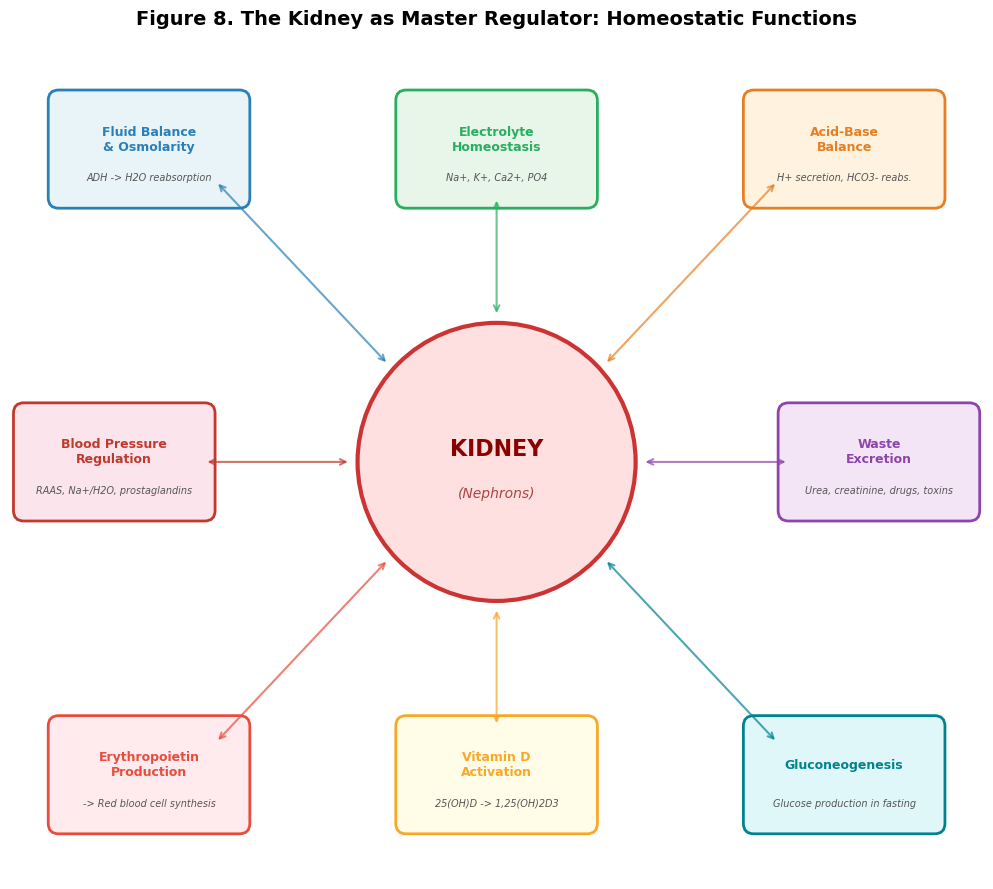

THE KIDNEY: NOT JUST A FILTER!
-------------------------------------------------------
  Regulates body fluid volume and osmolarity (ADH)
  Controls electrolyte levels (Na+, K+, Ca2+, PO4)
  Maintains acid-base balance (H+/HCO3-)
  Regulates blood pressure (RAAS system)
  Produces erythropoietin (-> red blood cell production)
  Activates vitamin D (calcium metabolism)
  Performs gluconeogenesis during fasting
  Excretes metabolic waste and drugs


In [26]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch
import numpy as np

fig, ax = plt.subplots(figsize=(14, 9))
ax.set_xlim(0, 14)
ax.set_ylim(0, 12)
ax.set_aspect('equal')
ax.axis('off')

# Central kidney
kidney = plt.Circle((7, 6), 2.0, facecolor='#ffe0e0', edgecolor='#cc3333', lw=3)
ax.add_patch(kidney)
ax.text(7, 6.2, 'KIDNEY', fontsize=16, ha='center', va='center',
        fontweight='bold', color='#880000')
ax.text(7, 5.5, '(Nephrons)', fontsize=10, ha='center', color='#aa4444',
        fontstyle='italic')

# Regulatory functions
functions = [
    (2.0, 10.5, 'Fluid Balance\n& Osmolarity', '#e8f4f8', '#2980b9',
     'ADH -> H2O reabsorption'),
    (7.0, 10.5, 'Electrolyte\nHomeostasis', '#e8f5e9', '#27ae60',
     'Na+, K+, Ca2+, PO4'),
    (12.0, 10.5, 'Acid-Base\nBalance', '#fff3e0', '#e67e22',
     'H+ secretion, HCO3- reabs.'),
    (1.5, 6.0, 'Blood Pressure\nRegulation', '#fce4ec', '#c0392b',
     'RAAS, Na+/H2O, prostaglandins'),
    (12.5, 6.0, 'Waste\nExcretion', '#f3e5f5', '#8e44ad',
     'Urea, creatinine, drugs, toxins'),
    (2.0, 1.5, 'Erythropoietin\nProduction', '#ffebee', '#e74c3c',
     '-> Red blood cell synthesis'),
    (7.0, 1.5, 'Vitamin D\nActivation', '#fffde7', '#f9a825',
     '25(OH)D -> 1,25(OH)2D3'),
    (12.0, 1.5, 'Gluconeogenesis', '#e0f7fa', '#00838f',
     'Glucose production in fasting'),
]

for x, y, title, fc, ec, detail in functions:
    box = FancyBboxPatch((x - 1.3, y - 0.7), 2.6, 1.4, boxstyle="round,pad=0.15",
                          facecolor=fc, edgecolor=ec, lw=2)
    ax.add_patch(box)
    ax.text(x, y + 0.15, title, fontsize=9, ha='center', va='center',
            fontweight='bold', color=ec)
    ax.text(x, y - 0.4, detail, fontsize=7, ha='center', va='center',
            color='#555', fontstyle='italic')

    dx = x - 7
    dy = y - 6
    dist = np.sqrt(dx**2 + dy**2)
    if dist > 2.5:
        nx, ny = dx/dist, dy/dist
        kx, ky = 7 + 2.1*nx, 6 + 2.1*ny
        bx, by = x - 1.3*nx, y - 0.7*ny
        ax.annotate('', xy=(bx, by), xytext=(kx, ky),
                    arrowprops=dict(arrowstyle='<->', color=ec, lw=1.5, alpha=0.7))

ax.set_title('Figure 8. The Kidney as Master Regulator: Homeostatic Functions',
             fontsize=14, fontweight='bold', pad=15)

plt.tight_layout()
plt.show()

print("THE KIDNEY: NOT JUST A FILTER!")
print("-" * 55)
print("  Regulates body fluid volume and osmolarity (ADH)")
print("  Controls electrolyte levels (Na+, K+, Ca2+, PO4)")
print("  Maintains acid-base balance (H+/HCO3-)")
print("  Regulates blood pressure (RAAS system)")
print("  Produces erythropoietin (-> red blood cell production)")
print("  Activates vitamin D (calcium metabolism)")
print("  Performs gluconeogenesis during fasting")
print("  Excretes metabolic waste and drugs")

## 9. DIY Exercises: Explore Further

### Exercise 1: Diabetes and Hyperfiltration

In early diabetic nephropathy, the GFR is paradoxically **elevated** (hyperfiltration, GFR > 140 mL/min) before it begins to decline. Modify the model to simulate this:

<details>
<summary>Click for starter code</summary>

```python
# Early diabetic nephropathy: afferent arteriole dilation -> increased P_GC
diabetic_params = KidneyParams(
    RPF_a=700,    # Increased renal blood flow
    GFR=150,      # Hyperfiltration
    P_GC=65,      # Increased capillary pressure (vasodilation)
    P_BC=15, pi_GC=30, pi_BC=0,
    P_xa=0.001, P_xv=0.0008, U_x=0.075, V_dot=1.2
)
diabetic_model = KidneyModel(diabetic_params)

print(f"Diabetic hyperfiltration:")
print(f"  GFR = {diabetic_params.GFR} mL/min (normal: 120)")
print(f"  FF  = {diabetic_params.FF:.1%} (normal: 20%)")
print(f"  NFP = {diabetic_params.net_filtration_pressure:.0f} mmHg (normal: 10)")

# Simulate capillary filtration and compare
cap_normal = model.simulate_capillary_filtration()
cap_diabetic = diabetic_model.simulate_capillary_filtration()

plt.figure(figsize=(10, 5))
plt.plot(cap_normal['position'], cap_normal['net_filtration_pressure'],
         'b-', lw=2, label='Normal')
plt.plot(cap_diabetic['position'], cap_diabetic['net_filtration_pressure'],
         'r-', lw=2, label='Diabetic hyperfiltration')
plt.xlabel('Position along capillary')
plt.ylabel('Net Filtration Pressure (mmHg)')
plt.title('Normal vs. Diabetic Hyperfiltration')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
```

</details>

<details>
<summary>Click to reveal what you should observe</summary>

- The diabetic kidney has **higher NFP** throughout the capillary
- Filtration is sustained for a longer portion of the capillary
- The increased mechanical stress on the glomerular filtration barrier contributes to **podocyte damage** and eventual **proteinuria**
- Over years, this leads to progressive scarring (glomerulosclerosis) and GFR decline
- **ACE inhibitors/ARBs** reduce efferent arteriolar tone, lowering $P_{GC}$ and reducing hyperfiltration --- this is why they are first-line treatment for diabetic nephropathy

</details>

---

### Exercise 2: Sensitivity Analysis --- What Parameters Most Affect GFR?

<details>
<summary>Click for starter code</summary>

```python
# Vary each Starling parameter by +/-30% and see effect on GFR
import numpy as np
import matplotlib.pyplot as plt

base = {'P_GC': 55, 'P_BC': 15, 'pi_GC': 30, 'pi_BC': 0}
K_f = 12.0  # mL/min/mmHg

param_names = list(base.keys())
fig, ax = plt.subplots(figsize=(10, 6))

for i, pname in enumerate(param_names):
    pct_changes = np.linspace(-30, 30, 50)
    gfr_values = []
    for pct in pct_changes:
        modified = base.copy()
        modified[pname] = base[pname] * (1 + pct/100)
        nfp = (modified['P_GC'] - modified['P_BC']) - (modified['pi_GC'] - modified['pi_BC'])
        gfr_values.append(K_f * nfp)
    ax.plot(pct_changes, gfr_values, lw=2, label=pname)

ax.axhline(y=120, color='gray', linestyle='--', lw=1, alpha=0.5)
ax.set_xlabel('% Change in Parameter')
ax.set_ylabel('GFR (mL/min)')
ax.set_title('Sensitivity Analysis: Effect of Starling Parameters on GFR')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()
```

</details>

<details>
<summary>Click to reveal interpretation</summary>

- **$P_{GC}$ has the largest effect** --- a 30% increase in capillary pressure increases GFR dramatically. This is why hypertension can cause hyperfiltration and eventual kidney damage.
- **$\pi_{GC}$** also has a large (negative) effect --- increased plasma protein concentration opposes filtration
- **$P_{BC}$** has a moderate negative effect --- increased back-pressure (e.g., from ureteral obstruction) reduces GFR
- **$\pi_{BC}$** has minimal effect (normally ~0 mmHg)

</details>

---

### Exercise 3: Drug Dosing Calculator

<details>
<summary>Click for starter code</summary>

```python
# Drug dosing adjustment based on eGFR
def drug_dose_adjustment(egfr, drug_name):
    adjustments = {
        'Metformin': [(60, '-> Full dose (500-2000 mg/day)'),
                      (30, '-> Reduce to max 1000 mg/day'),
                      (0,  '-> CONTRAINDICATED')],
        'Gentamicin': [(80, '-> Normal dose, normal interval'),
                       (50, '-> Normal dose, extend interval to 12h'),
                       (30, '-> Reduce dose AND extend interval'),
                       (0,  '-> Avoid or use with extreme caution')],
    }
    if drug_name in adjustments:
        for threshold, recommendation in adjustments[drug_name]:
            if egfr >= threshold:
                return recommendation
    return "No data available"

# Test with different patients
for scr, age, sex in [(0.9, 45, 'M'), (1.8, 70, 'F'), (3.5, 60, 'M')]:
    e = egfr_ckd_epi_2021(scr, age, sex)
    print(f"\nPatient: SCr={scr}, Age={age}, Sex={sex}")
    print(f"  eGFR = {e:.0f} mL/min -> {ckd_stage(e)}")
    for drug in ['Metformin', 'Gentamicin']:
        print(f"  {drug}: {drug_dose_adjustment(e, drug)}")
```

</details>

## 10. Going Deeper

### Extensions and advanced topics

The kidney filtration model presented here can be extended in many directions:

- **Tubuloglomerular feedback (TGF)**: A negative feedback loop where NaCl concentration at the macula densa regulates afferent arteriolar tone. This can be modeled as a delay differential equation
- **RAAS modeling**: The renin-angiotensin-aldosterone system involves multiple compartments and feedback loops --- amenable to systems pharmacology modeling
- **Compartmental pharmacokinetic models**: Drug distribution and elimination through the kidney can be modeled using multi-compartment ODE systems
- **Dynamic contrast-enhanced MRI (DCE-MRI)**: Model-based analysis of Gd-contrast enhancement curves to estimate single-kidney GFR non-invasively. Uses tracer kinetic models (Tofts, two-compartment exchange models)
- **Whole-kidney simulation**: Combining models of individual nephrons (with heterogeneous properties) to simulate whole-kidney function --- a computational challenge similar to multi-scale cardiac modeling
- **Machine learning for eGFR**: Neural networks trained on large clinical datasets may improve GFR prediction beyond traditional equations

### Key references

1. **Smith, H.W.** (1951). *The Kidney: Structure and Function in Health and Disease*. Oxford University Press. [The classic textbook by the father of renal physiology]
2. **Levey, A.S. et al.** (2009). A new equation to estimate glomerular filtration rate. *Ann. Intern. Med.* 150:604--612. [The CKD-EPI equation]
3. **Inker, L.A. et al.** (2021). New creatinine- and cystatin C-based equations to estimate GFR without race. *N. Engl. J. Med.* 385:1737--1749. [The race-free CKD-EPI 2021 update]
4. **Deen, W.M., Robertson, C.R. & Brenner, B.M.** (1972). A model of glomerular ultrafiltration in the rat. *Am. J. Physiol.* 223:1178--1183. [Mathematical model of glomerular filtration]
5. **KDIGO Clinical Practice Guidelines** for CKD: https://kdigo.org/guidelines/ckd-evaluation-and-management/
6. **Boron, W.F. & Boulpaep, E.L.** (2017). *Medical Physiology*, 3rd ed. Elsevier. [Chapters 33--40 on renal physiology]

### Useful online resources
- NIDDK --- The Kidneys and How They Work: https://www.niddk.nih.gov/health-information/kidney-disease
- Kidney Disease: Improving Global Outcomes (KDIGO): https://kdigo.org/
- CKD-EPI online calculator: https://www.kidney.org/professionals/kdoqi/gfr_calculator
- PhysioNet --- Renal physiology resources: https://physionet.org/

### Connections to other Lab 5 notebooks
- **01-action-potentials**: The kidney's tubuloglomerular feedback uses neural-like signaling; afferent arteriolar tone is modulated by neural input
- **03-cardiovascular-flow**: Renal blood flow regulation is a key component of cardiovascular physiology
- **05-cell-signaling**: The RAAS system involves receptor-mediated cell signaling cascades
- **07-cybernetics-of-wound-healing**: Kidney homeostasis exemplifies cybernetic feedback control

---

**Notebook summary**: This notebook developed a computational model of kidney filtration, covering the anatomical basis (nephron structure, glomerular filtration barrier), the mathematical framework (mass balance, Starling equation, clearance), clinical applications (CKD staging, eGFR estimation, drug dosing), and advanced topics (DCE-MRI, machine learning). The Python implementation allows interactive exploration of how hemodynamic and pathological changes affect kidney function.

*Created for BMED365 --- Computational Medicine, University of Bergen, 2026.*